# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [314]:
# Installing the libraries with the specified version
import sys

!{sys.executable} -m pip install --no-deps tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [315]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
#Imports metrics from
from sklearn import metrics

#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization, Dropout
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [316]:
# uncomment and run the following lines for Google Colab
renewind_train = pd.read_csv("Train.csv")
renewind_test = pd.read_csv("Test.csv")

df = renewind_train.copy()
df_test = renewind_test.copy()

# **Data Overview**

In [317]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [318]:
#shape of training data
df.shape

(20000, 41)

#### Observation
- training data has 20k rows and 41 columns


In [319]:
#shape of test data
df_test.shape

(5000, 41)

#### Observation
- test data has 5k rows and 41 colums

In [320]:
# test data sample
df_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


### Data type of data

In [321]:
#training data datatypes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [322]:
#data type of test data set
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

#### Observation
- both test and training data have 40 of thier columns as float and one of their column as integer

### Duplicate check

In [323]:
#training data set duplicate check
df.duplicated().sum()

0

In [324]:
#test data set duplicate check
df_test.duplicated().sum()

0

#### Observation
- both test and training data set have no duplicate

### Missing data check

In [325]:
#training data mising values check
df.isnull().sum()

V1        18
V2        18
V3         0
V4         0
V5         0
V6         0
V7         0
V8         0
V9         0
V10        0
V11        0
V12        0
V13        0
V14        0
V15        0
V16        0
V17        0
V18        0
V19        0
V20        0
V21        0
V22        0
V23        0
V24        0
V25        0
V26        0
V27        0
V28        0
V29        0
V30        0
V31        0
V32        0
V33        0
V34        0
V35        0
V36        0
V37        0
V38        0
V39        0
V40        0
Target     0
dtype: int64

In [326]:
#test data set null check
df_test.isnull().sum()

V1        5
V2        6
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
V29       0
V30       0
V31       0
V32       0
V33       0
V34       0
V35       0
V36       0
V37       0
V38       0
V39       0
V40       0
Target    0
dtype: int64

#### Observation
- In training data set there are 18 rows where the columns V1 and V2 values are null 
- In test data set there are 5 rows where the columns V1 is null and 6 rows where V2 column is null

### Statistical summary of the dataset


In [327]:
#statistical summary of training data set
df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


In [328]:
#statistical summary of test data set
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,4995.0,-0.277622,3.466280,-12.381696,-2.743691,-0.764767,1.831313,13.504352
V2,4994.0,0.397928,3.139562,-10.716179,-1.649211,0.427369,2.444486,14.079073
V3,5000.0,2.551787,3.326607,-9.237940,0.314931,2.260428,4.587000,15.314503
V4,5000.0,-0.048943,3.413937,-14.682446,-2.292694,-0.145753,2.166468,12.140157
V5,5000.0,-0.080120,2.110870,-7.711569,-1.615238,-0.131890,1.341197,7.672835
V6,5000.0,-1.042138,2.005444,-8.924196,-2.368853,-1.048571,0.307555,5.067685
V7,5000.0,-0.907922,1.769017,-8.124230,-2.054259,-0.939695,0.212228,7.616182
V8,5000.0,-0.574592,3.331911,-12.252731,-2.642088,-0.357943,1.712896,10.414722
V9,5000.0,0.030121,2.174139,-6.785495,-1.455712,-0.079891,1.449548,8.850720
V10,5000.0,0.018524,2.145437,-8.170956,-1.353320,0.166292,1.511248,6.598728


# **Exploratory Data Analysis**

## Univariate analysis

In [329]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Variables V1 to V29

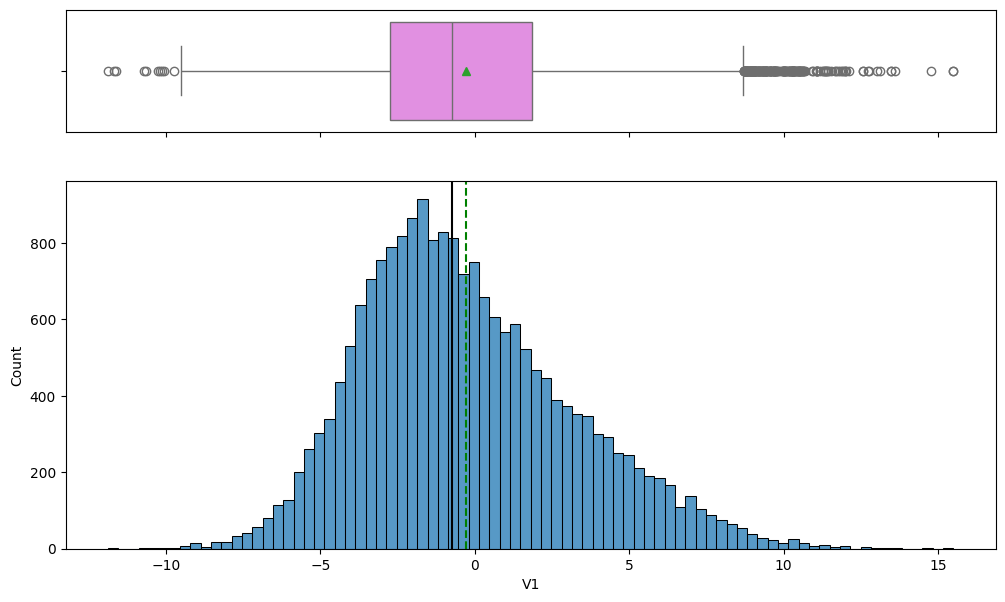

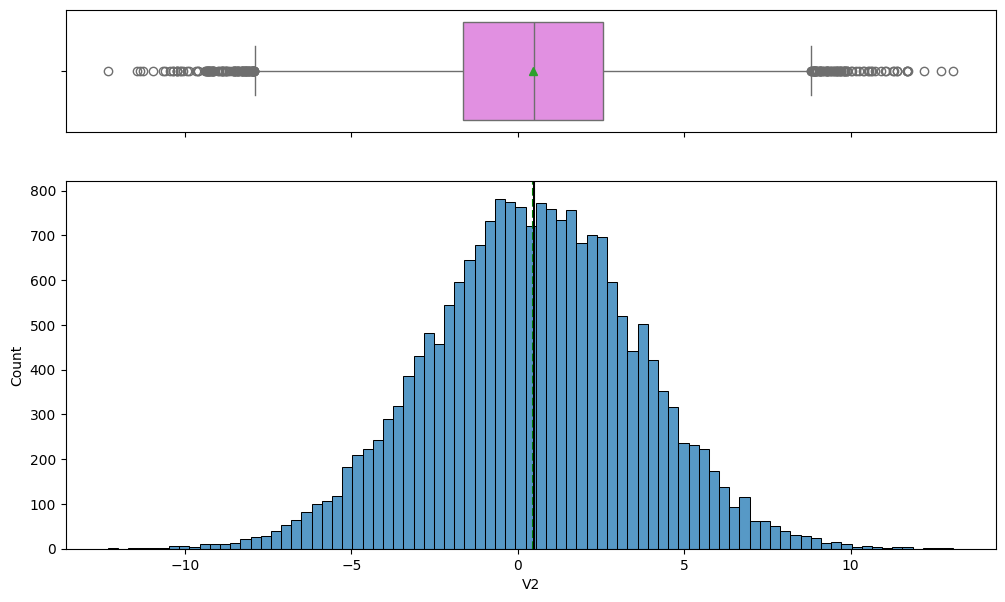

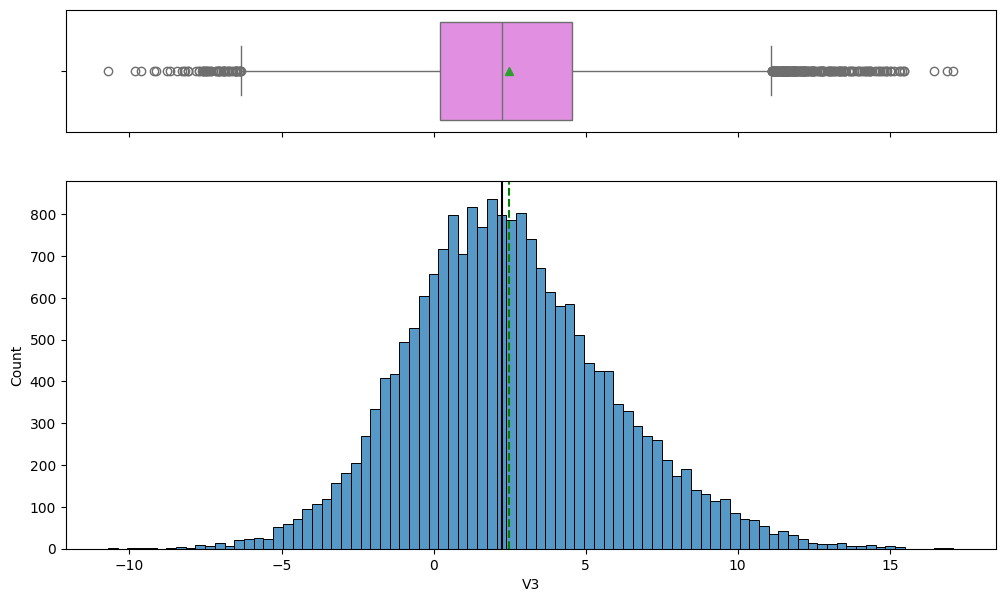

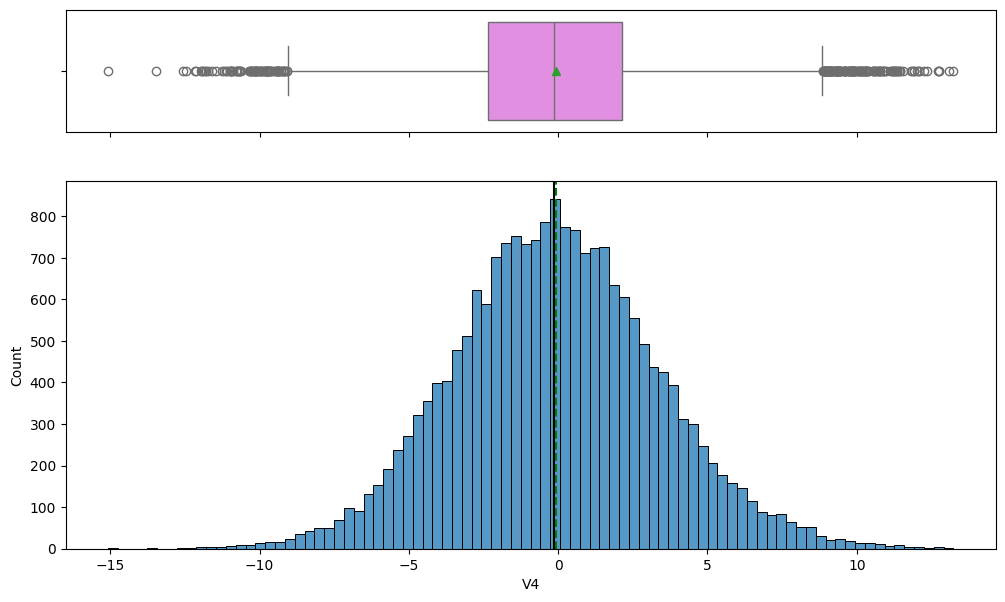

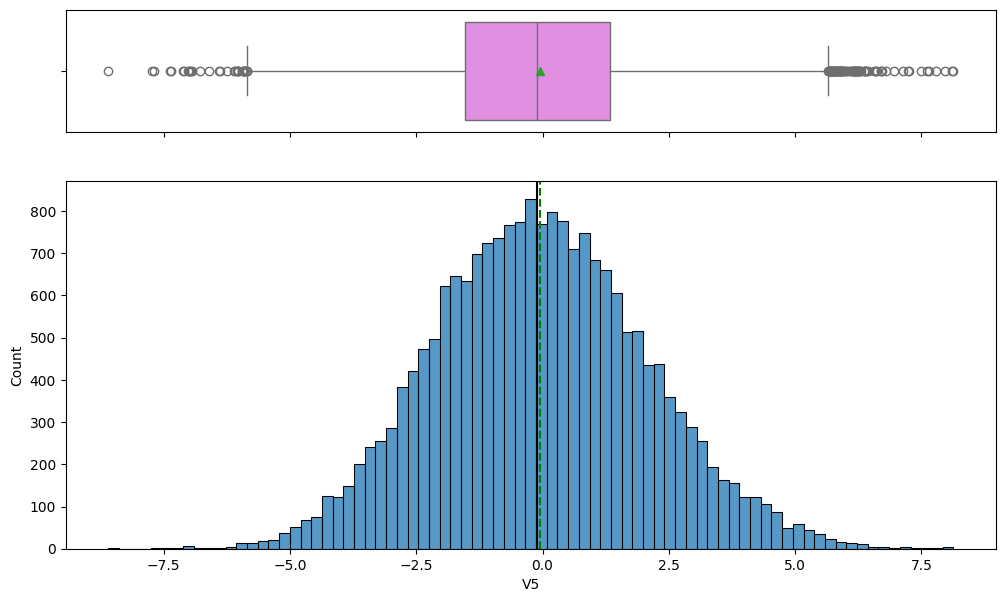

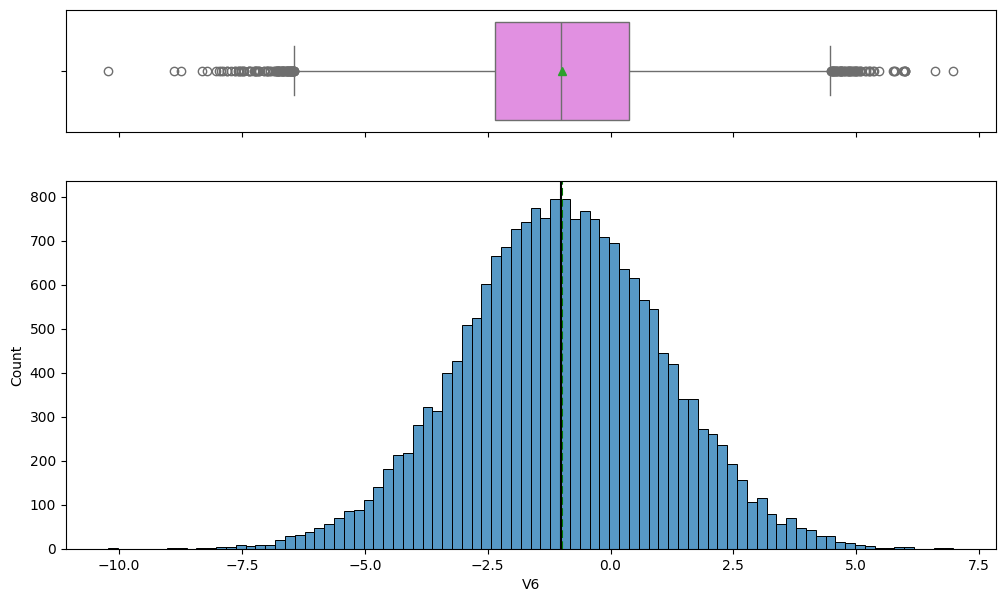

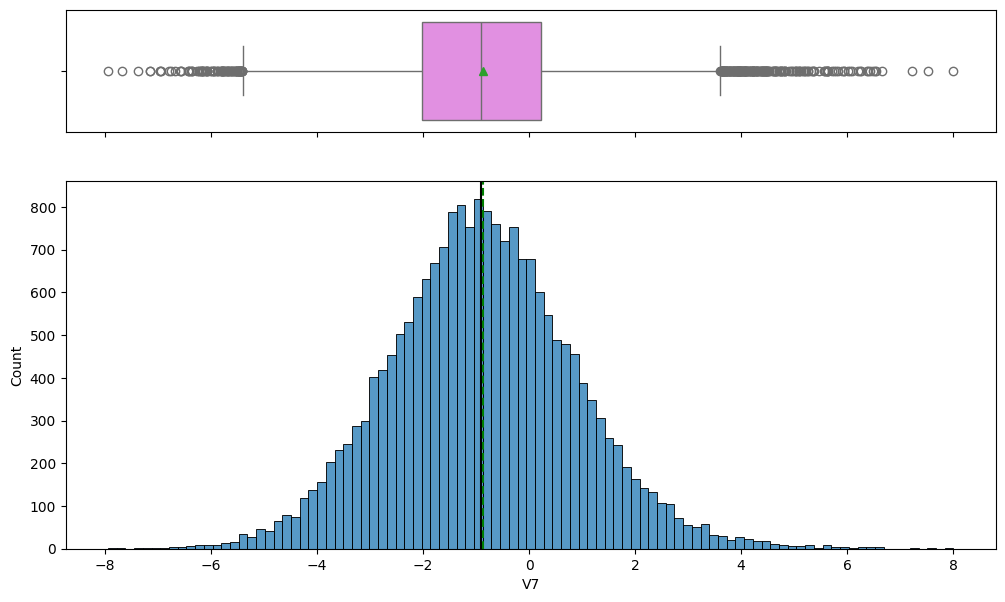

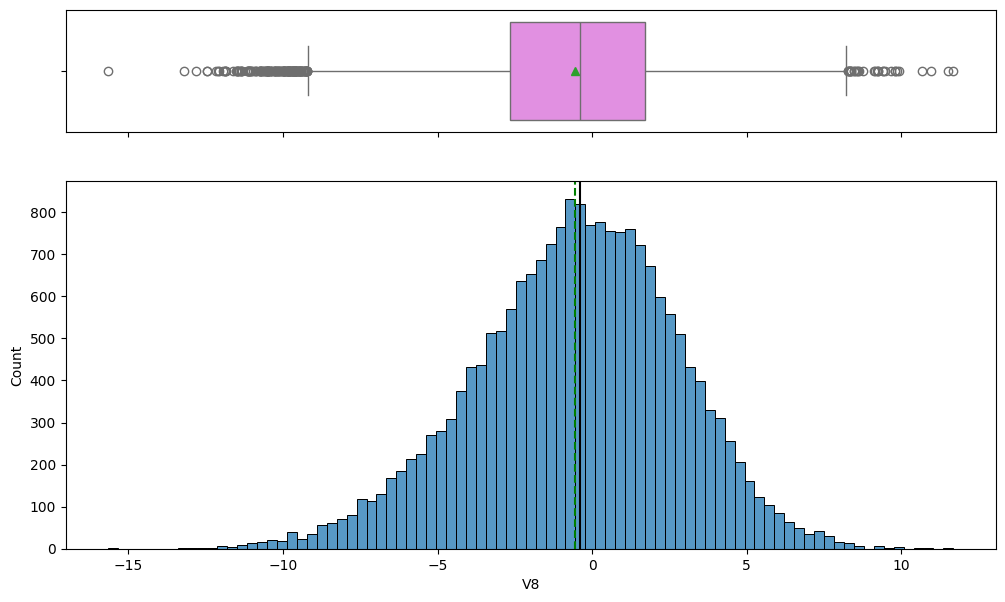

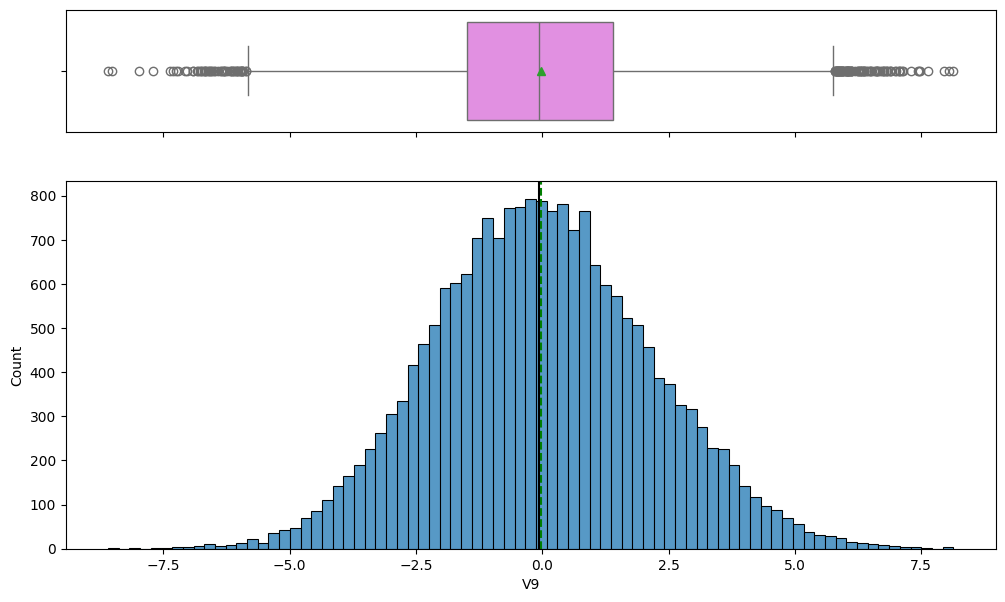

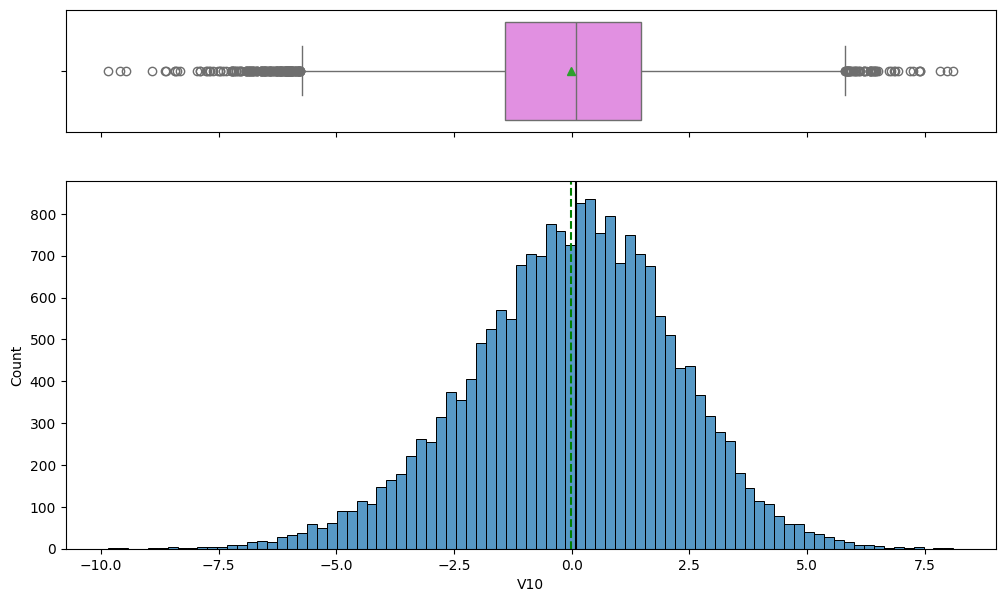

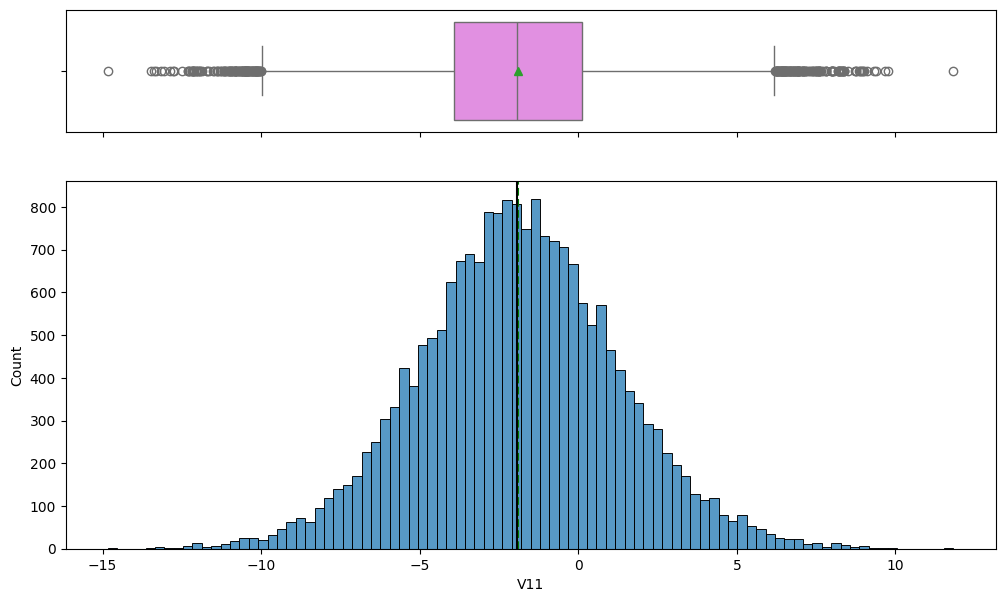

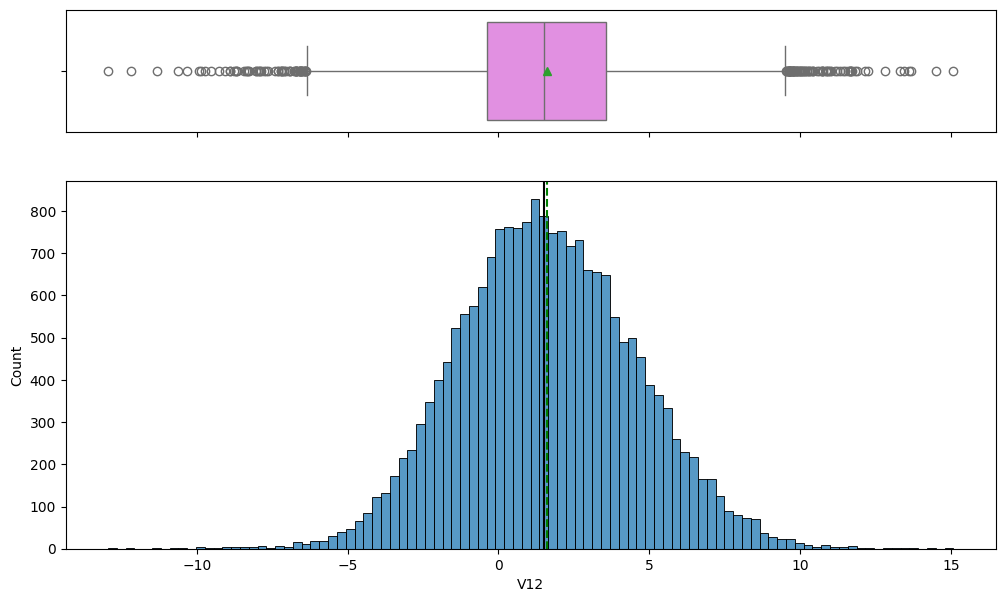

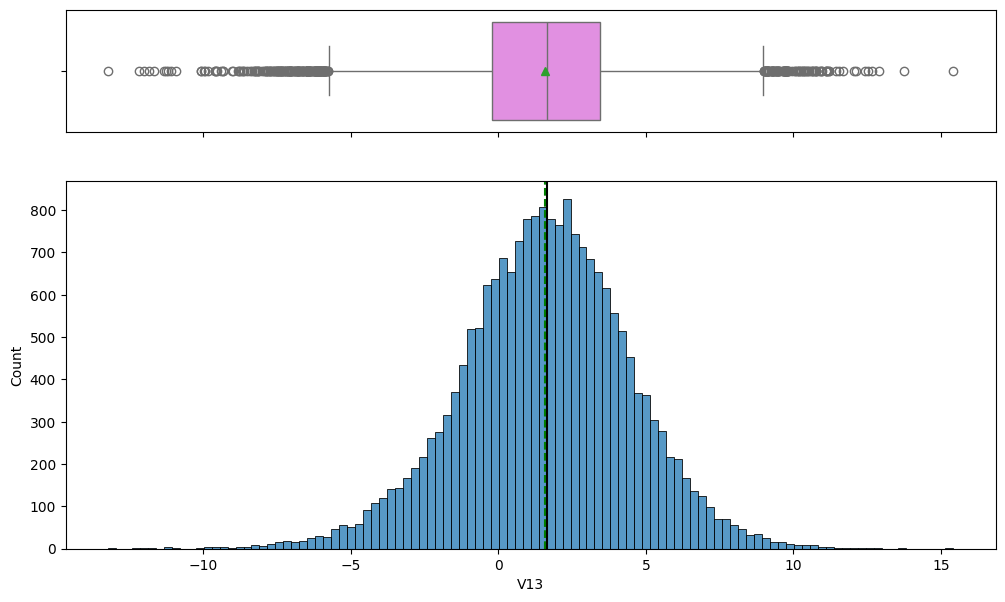

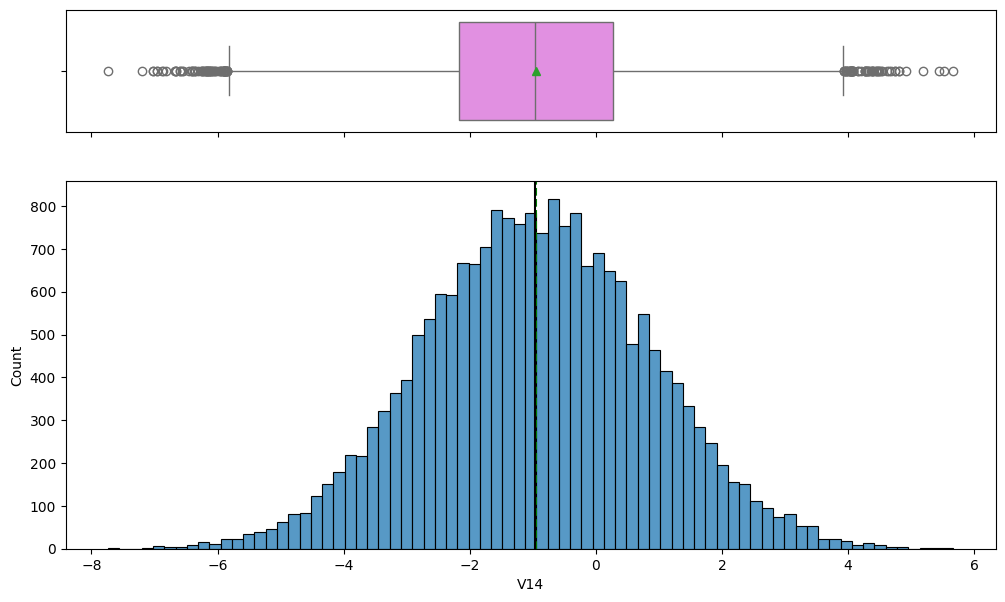

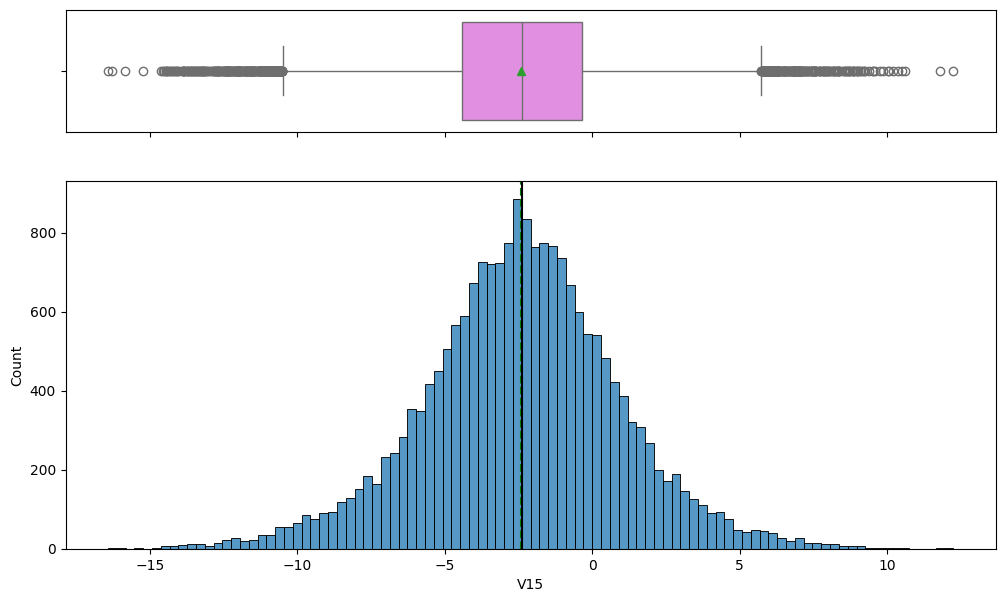

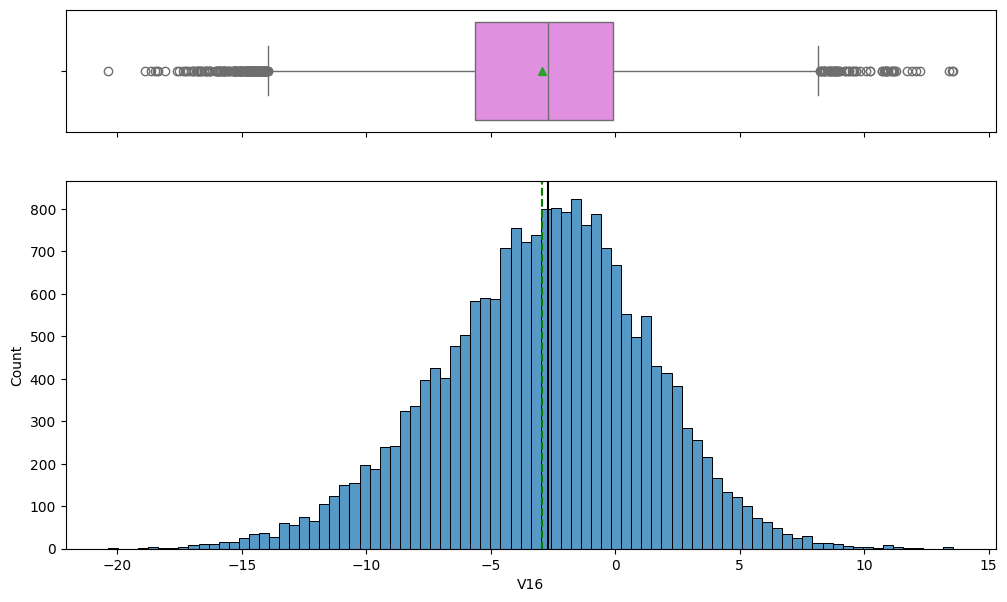

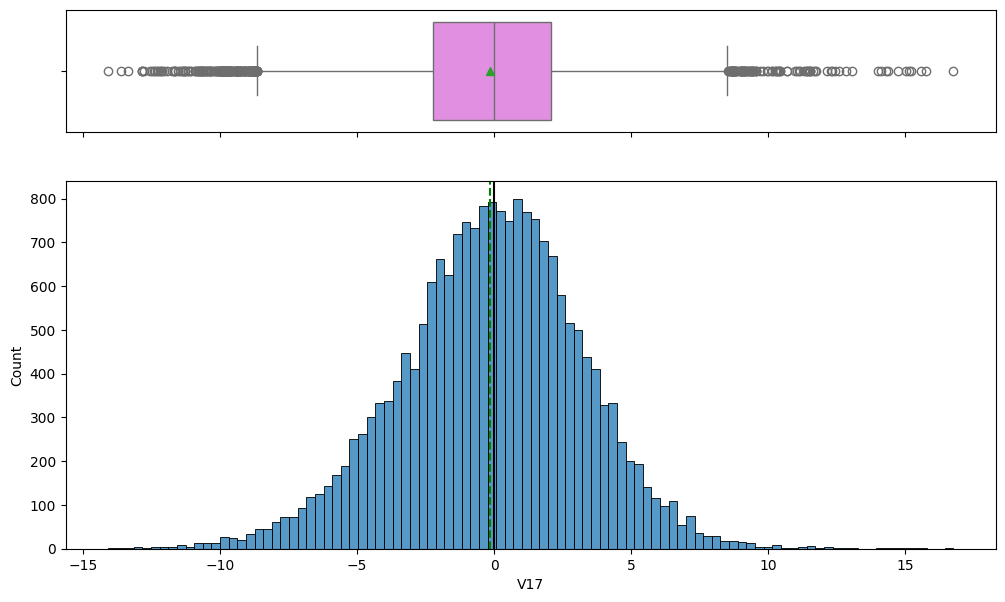

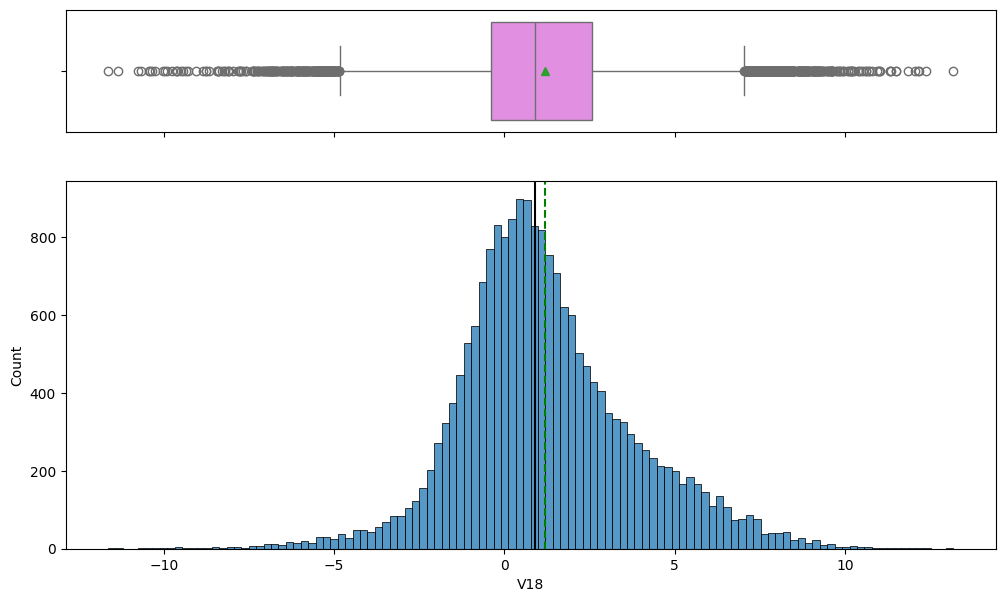

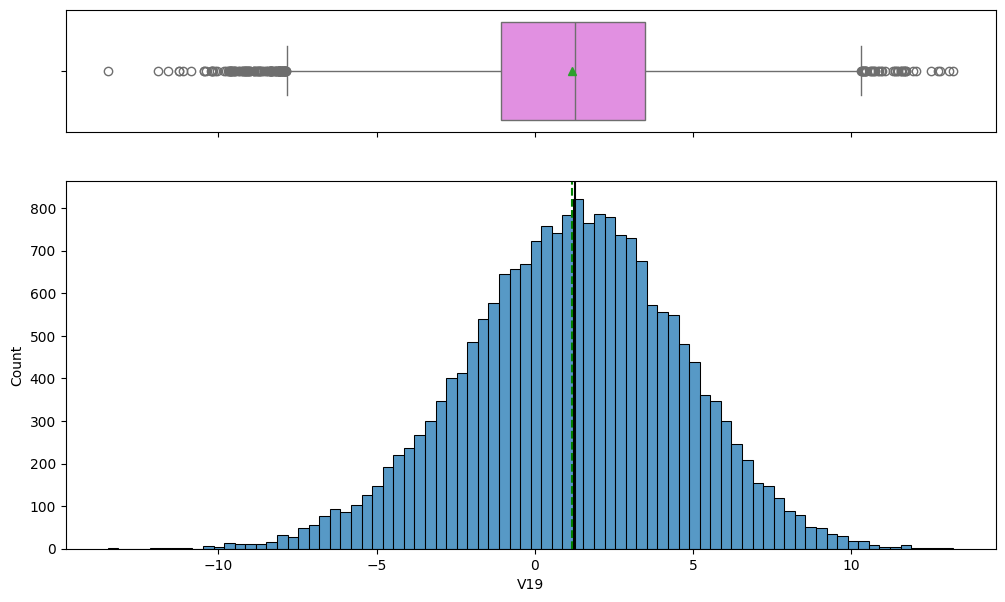

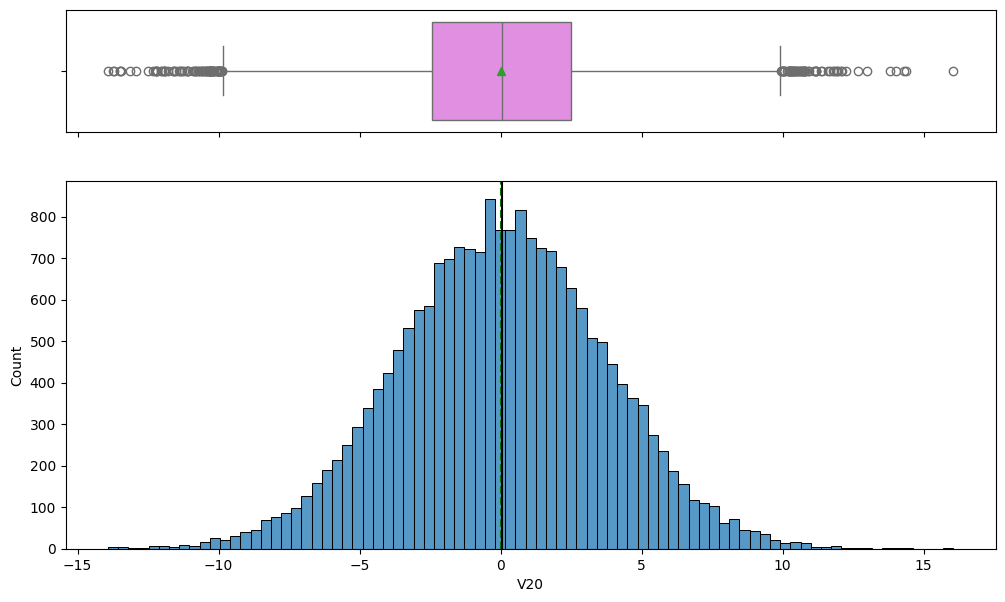

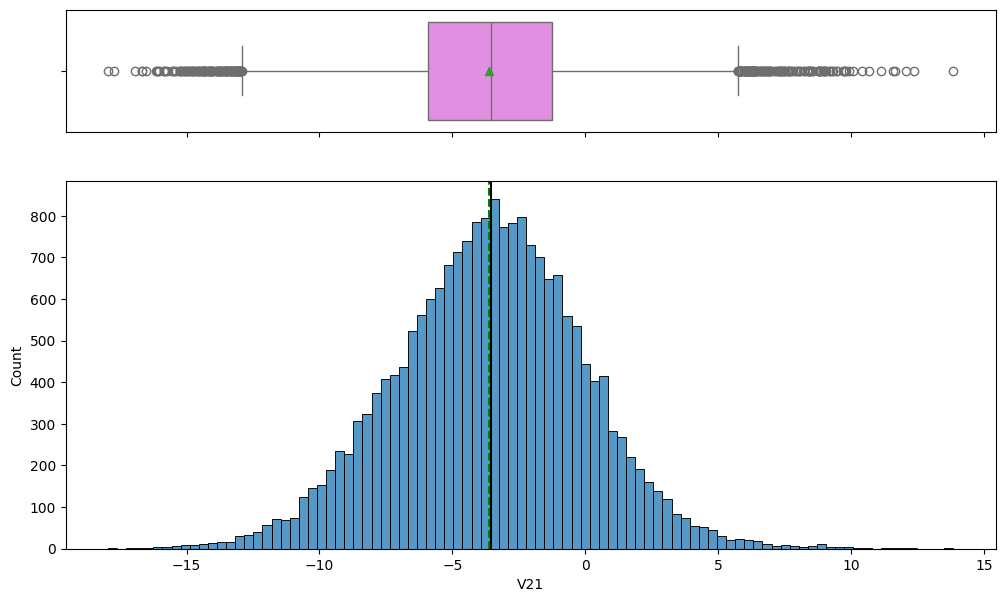

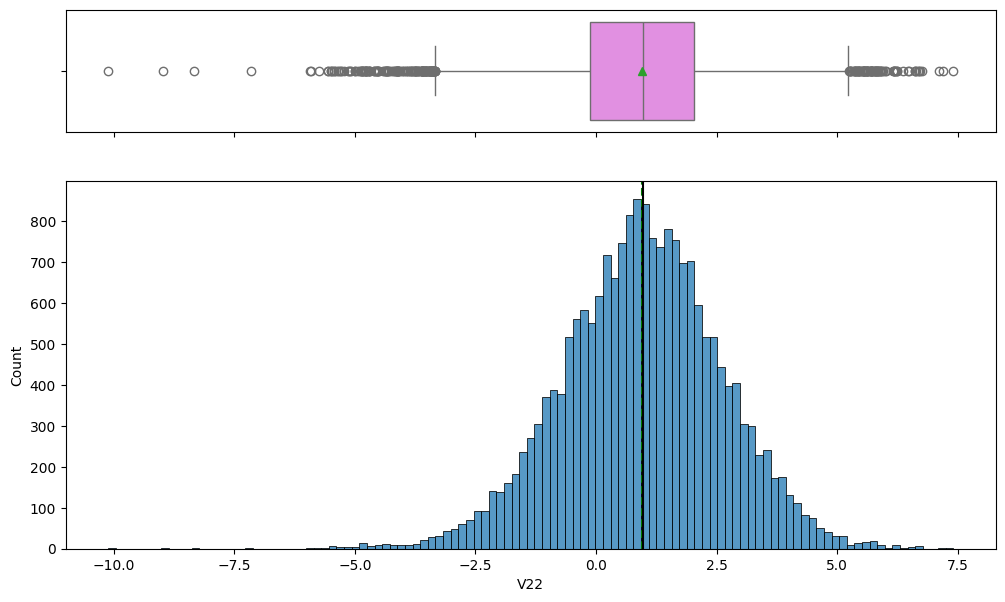

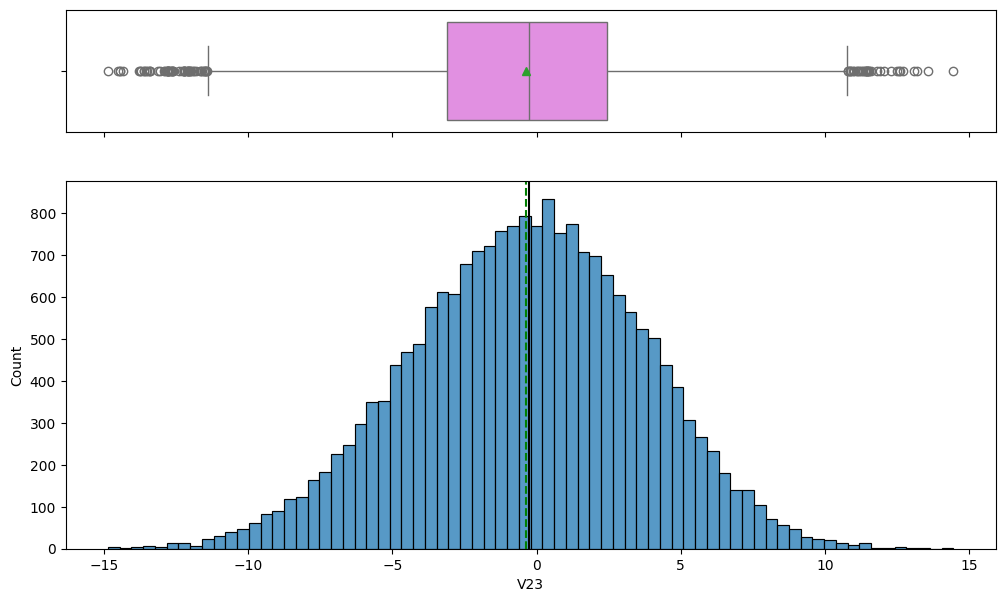

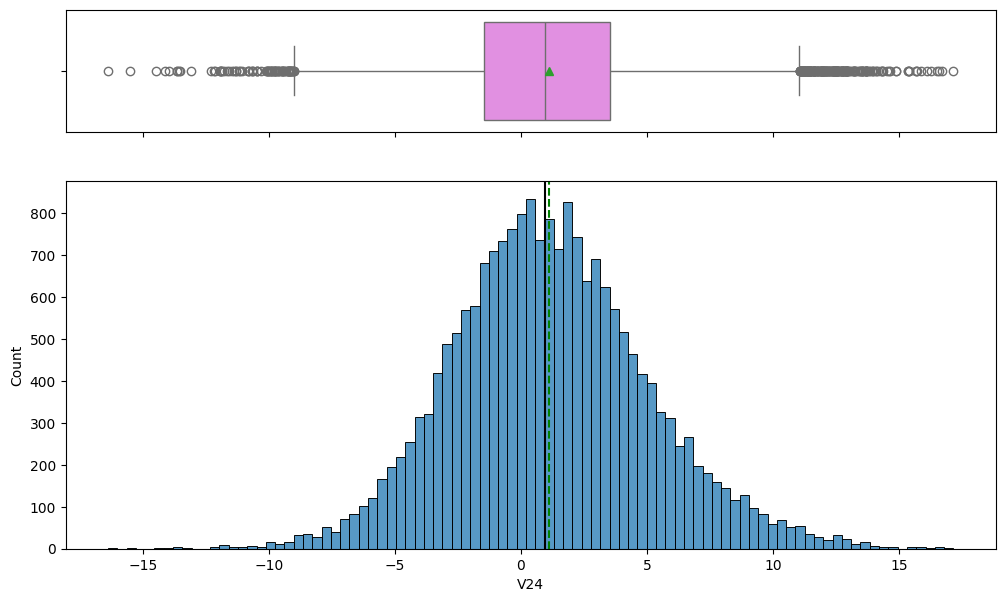

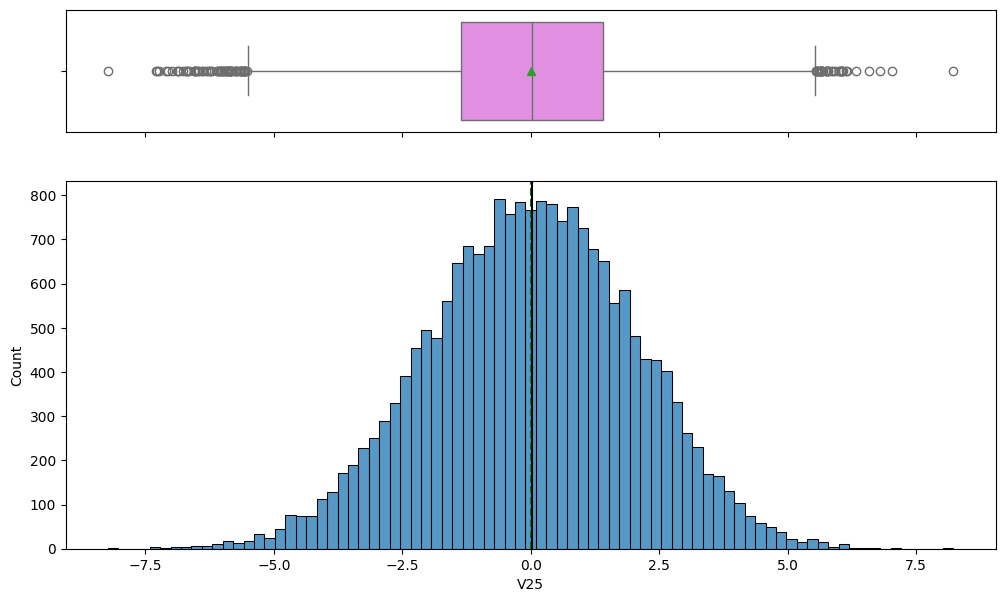

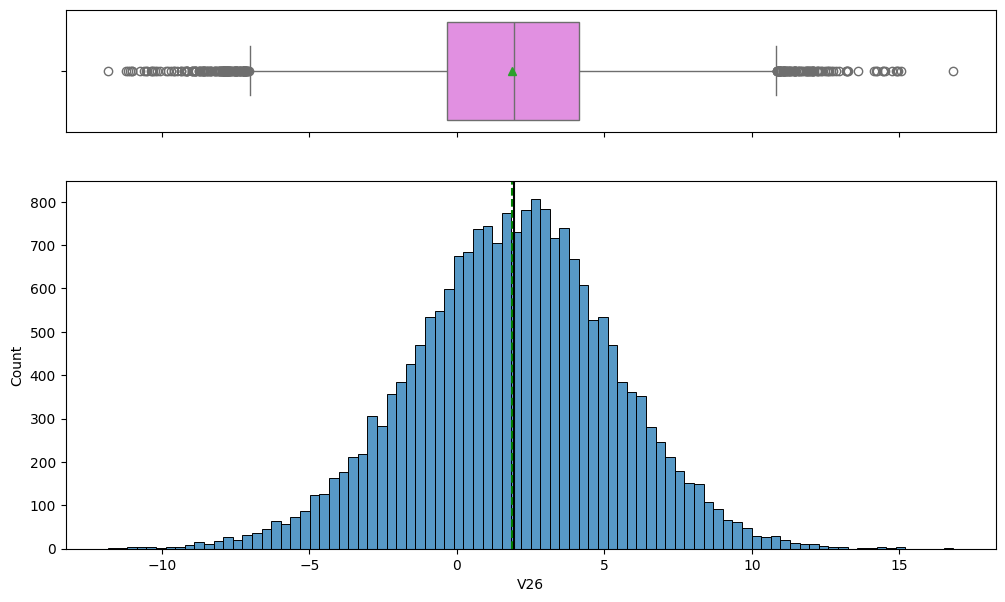

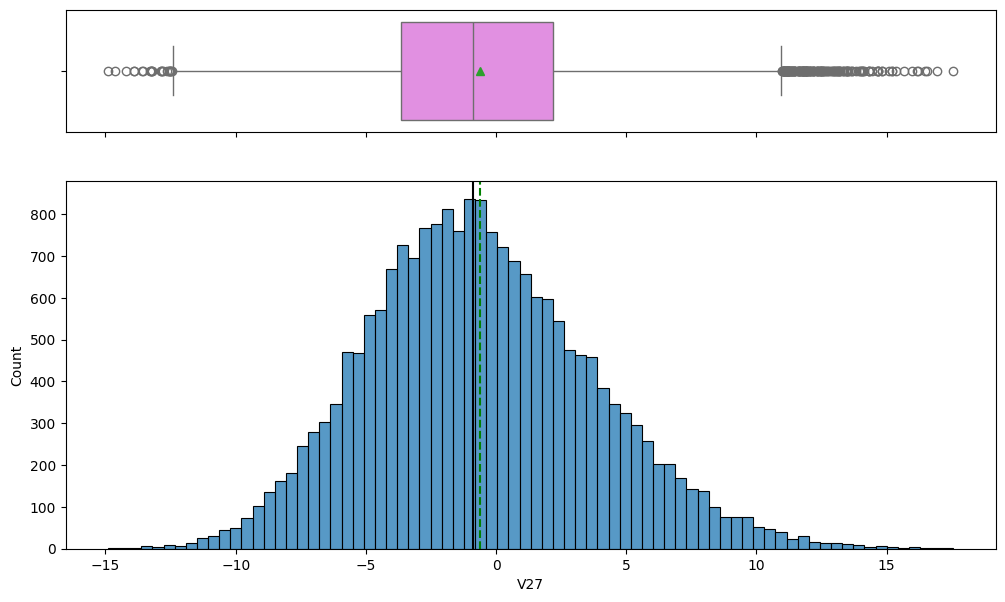

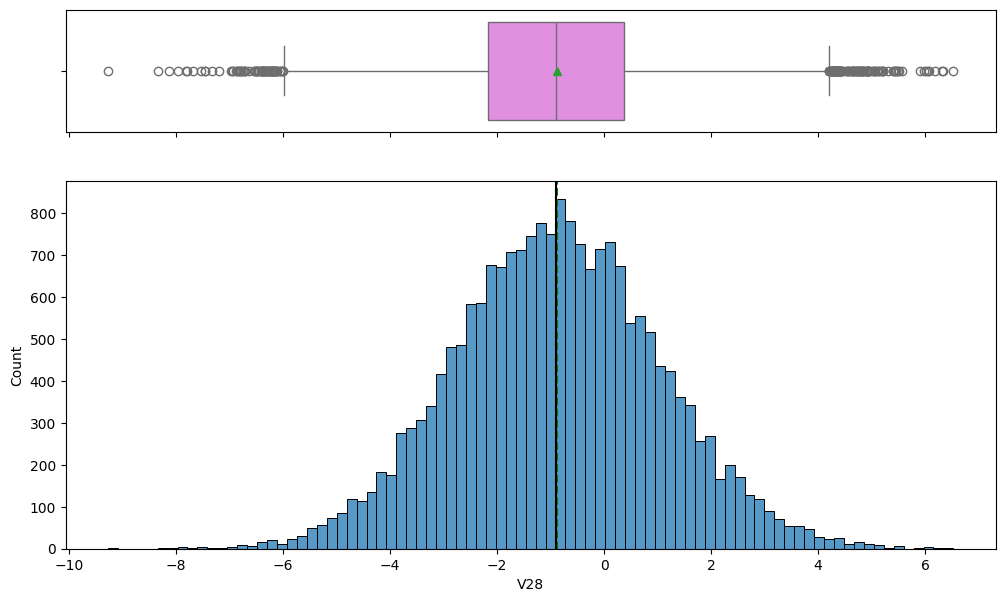

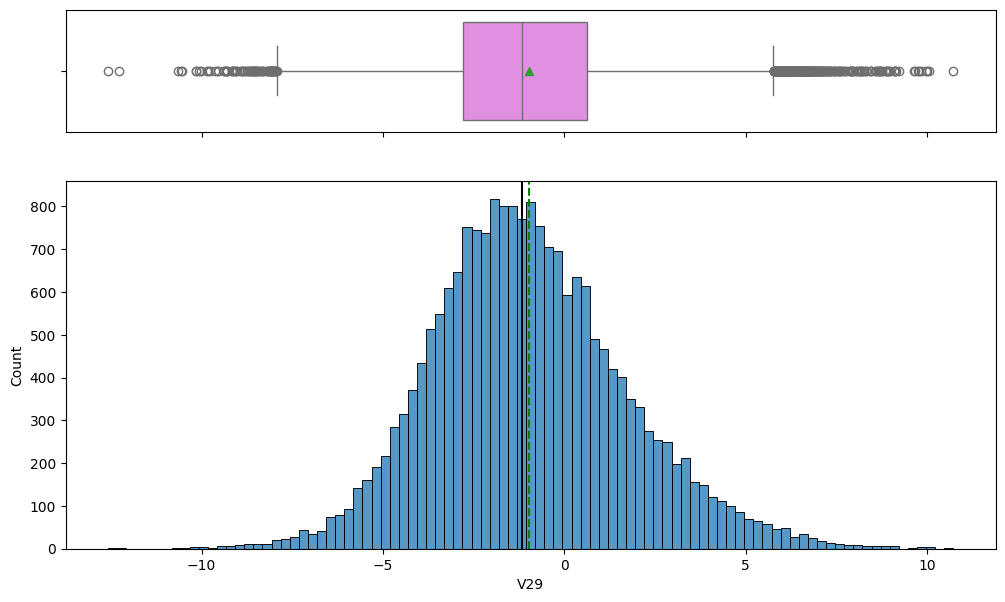

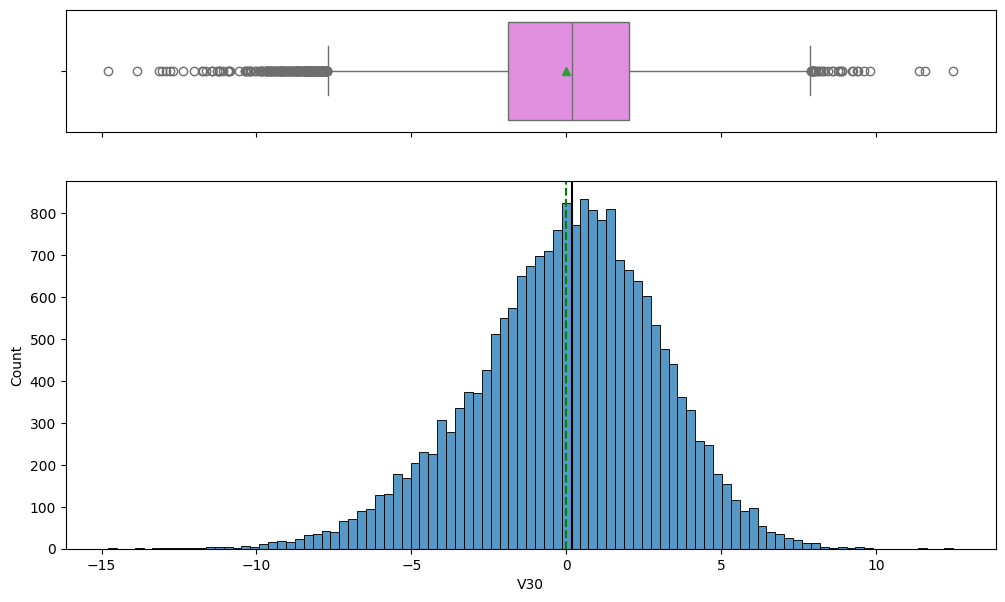

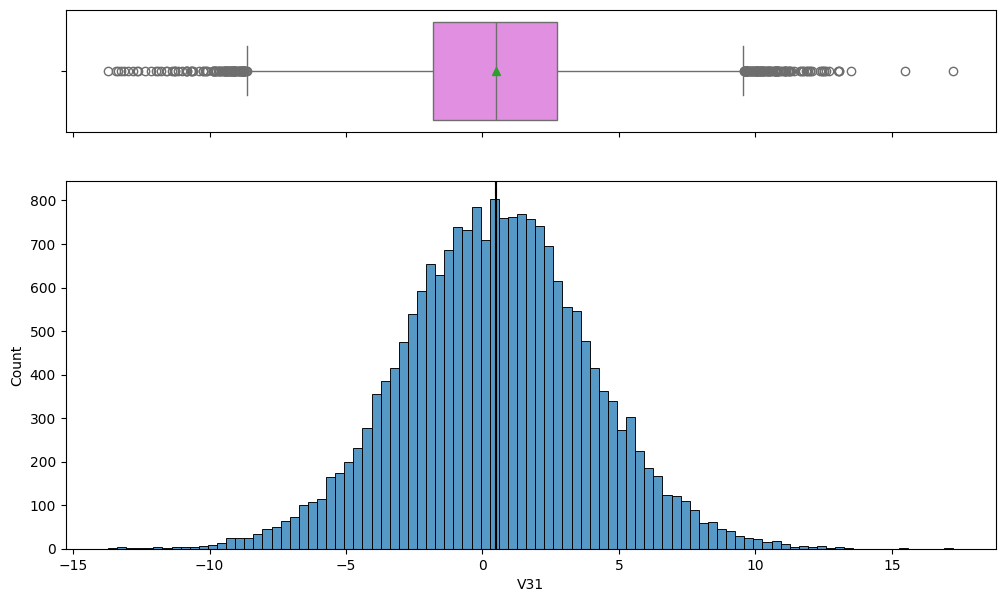

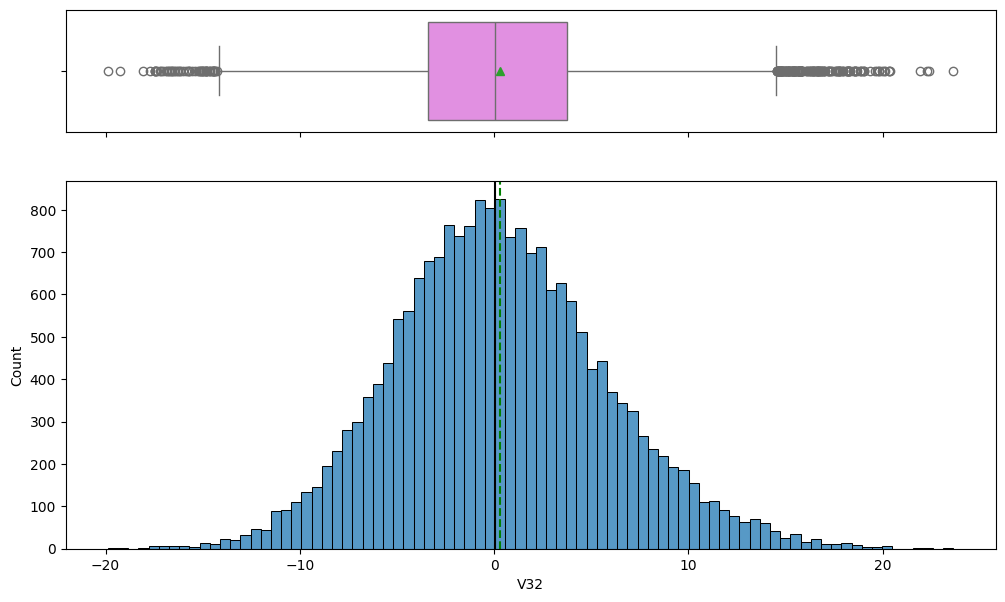

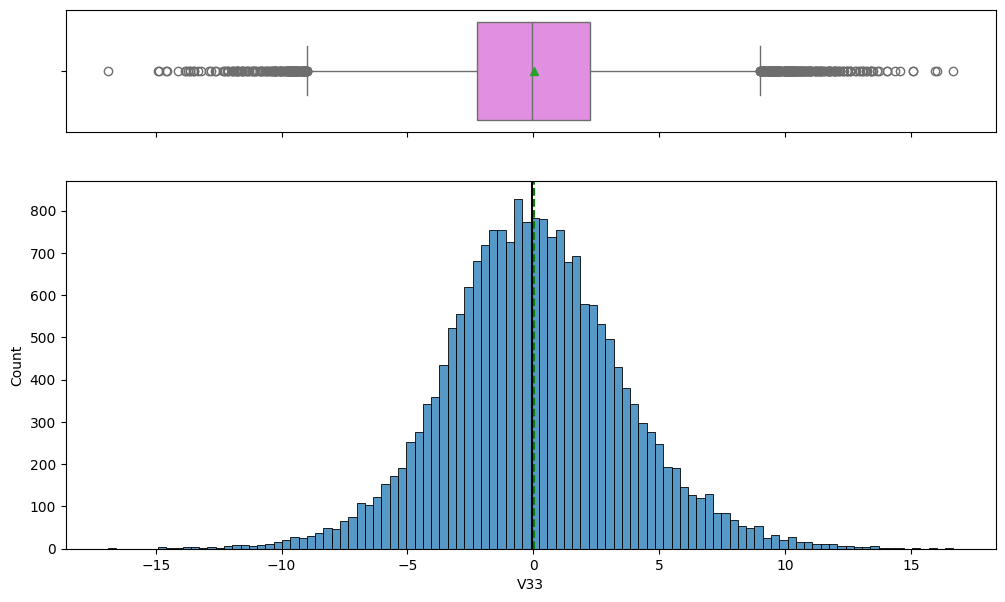

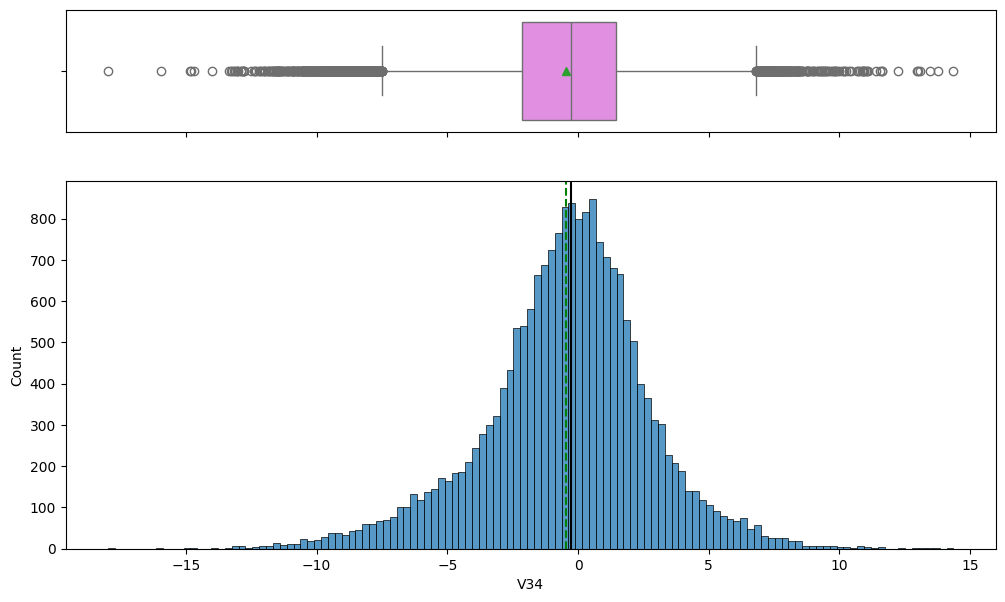

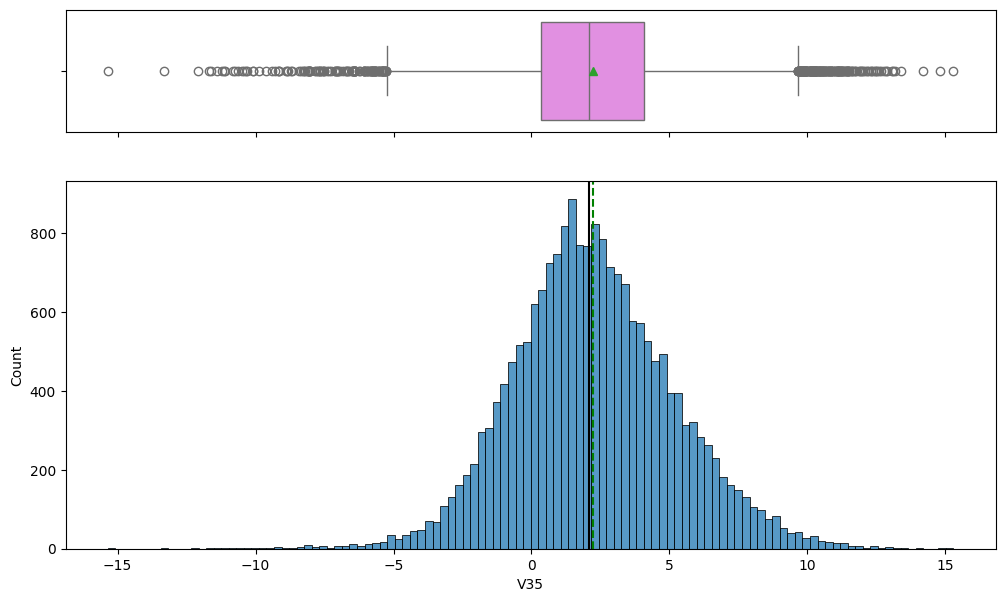

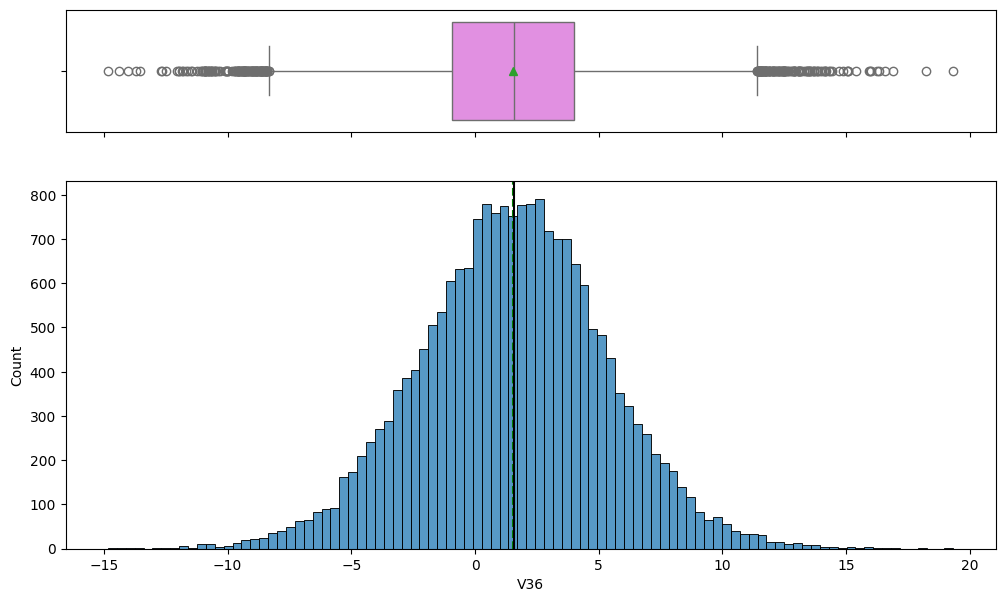

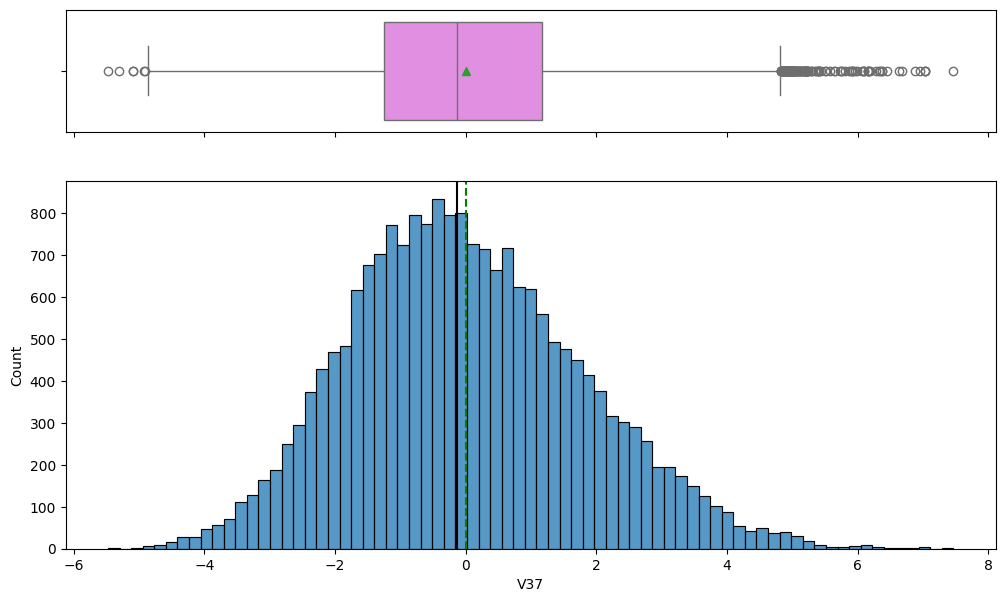

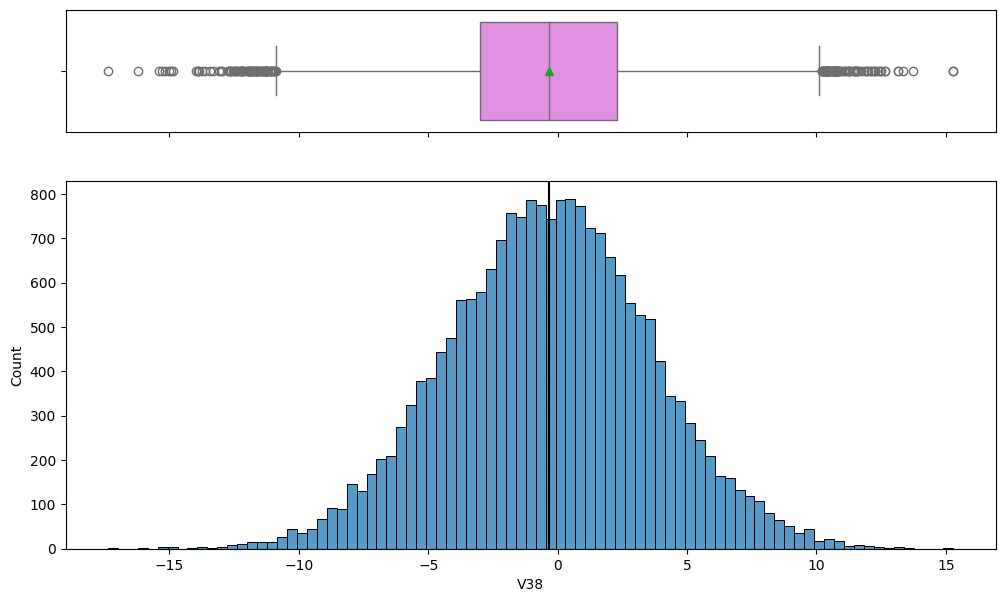

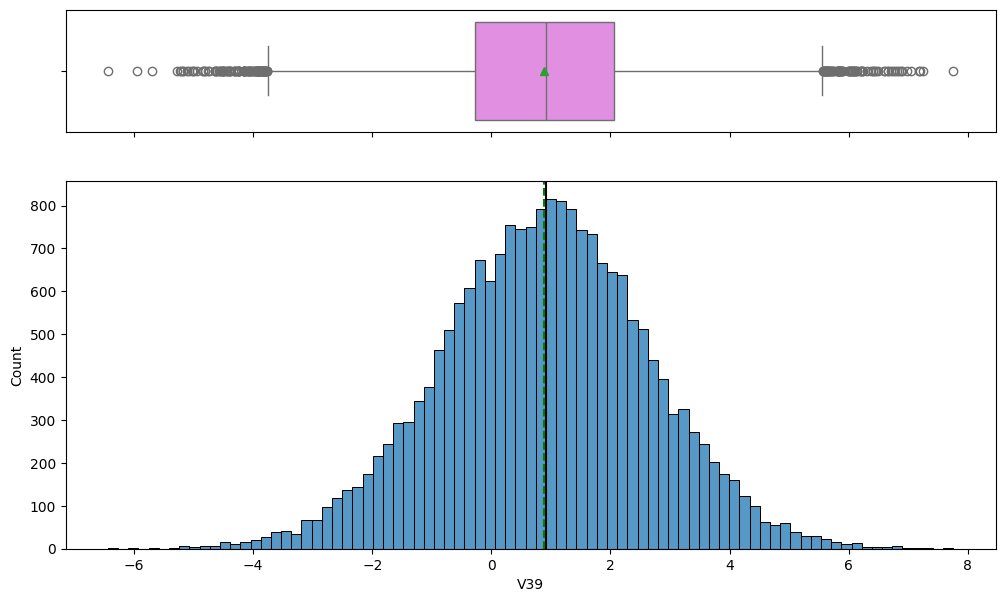

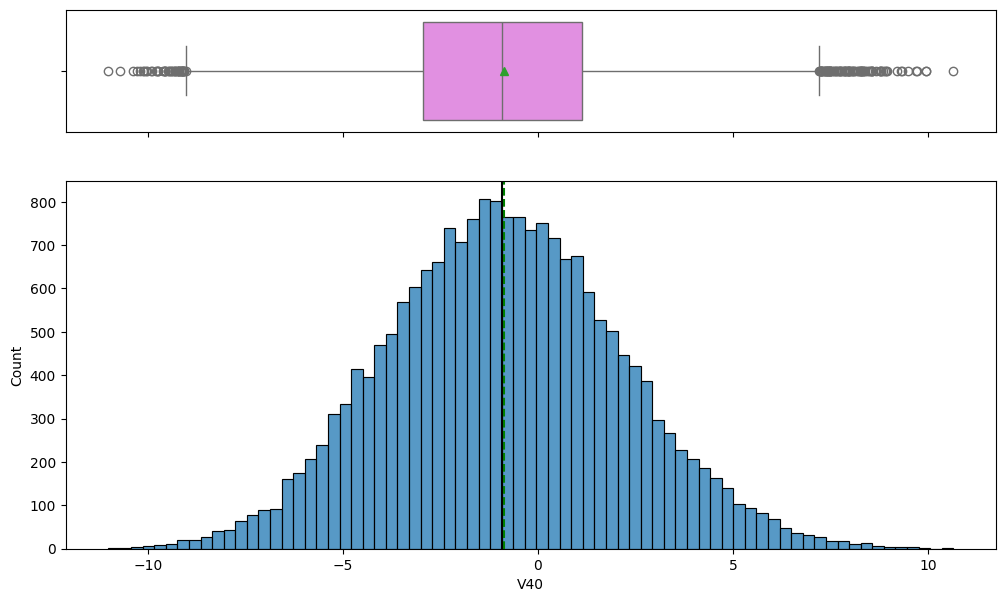

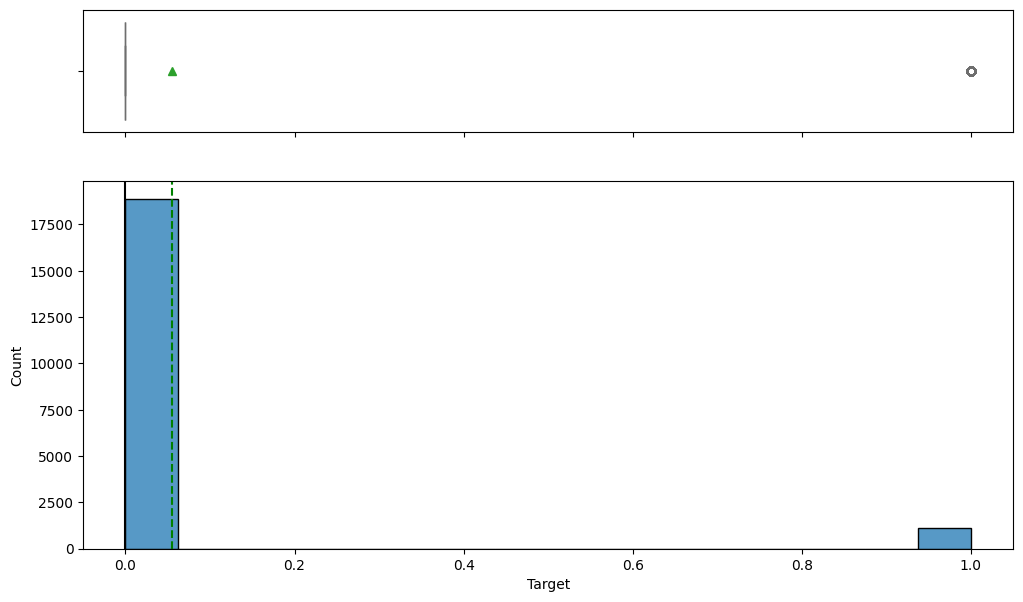

In [330]:
for feature in df.columns:
    histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None)

### Checking the distrubution of Target variable


In [331]:
# training data set target variable distribution
df["Target"].value_counts(1)

Target
0    0.9445
1    0.0555
Name: proportion, dtype: float64

In [332]:
# test data set target variable distribution
df_test["Target"].value_counts(1)


Target
0    0.9436
1    0.0564
Name: proportion, dtype: float64

## Bivariate Analysis

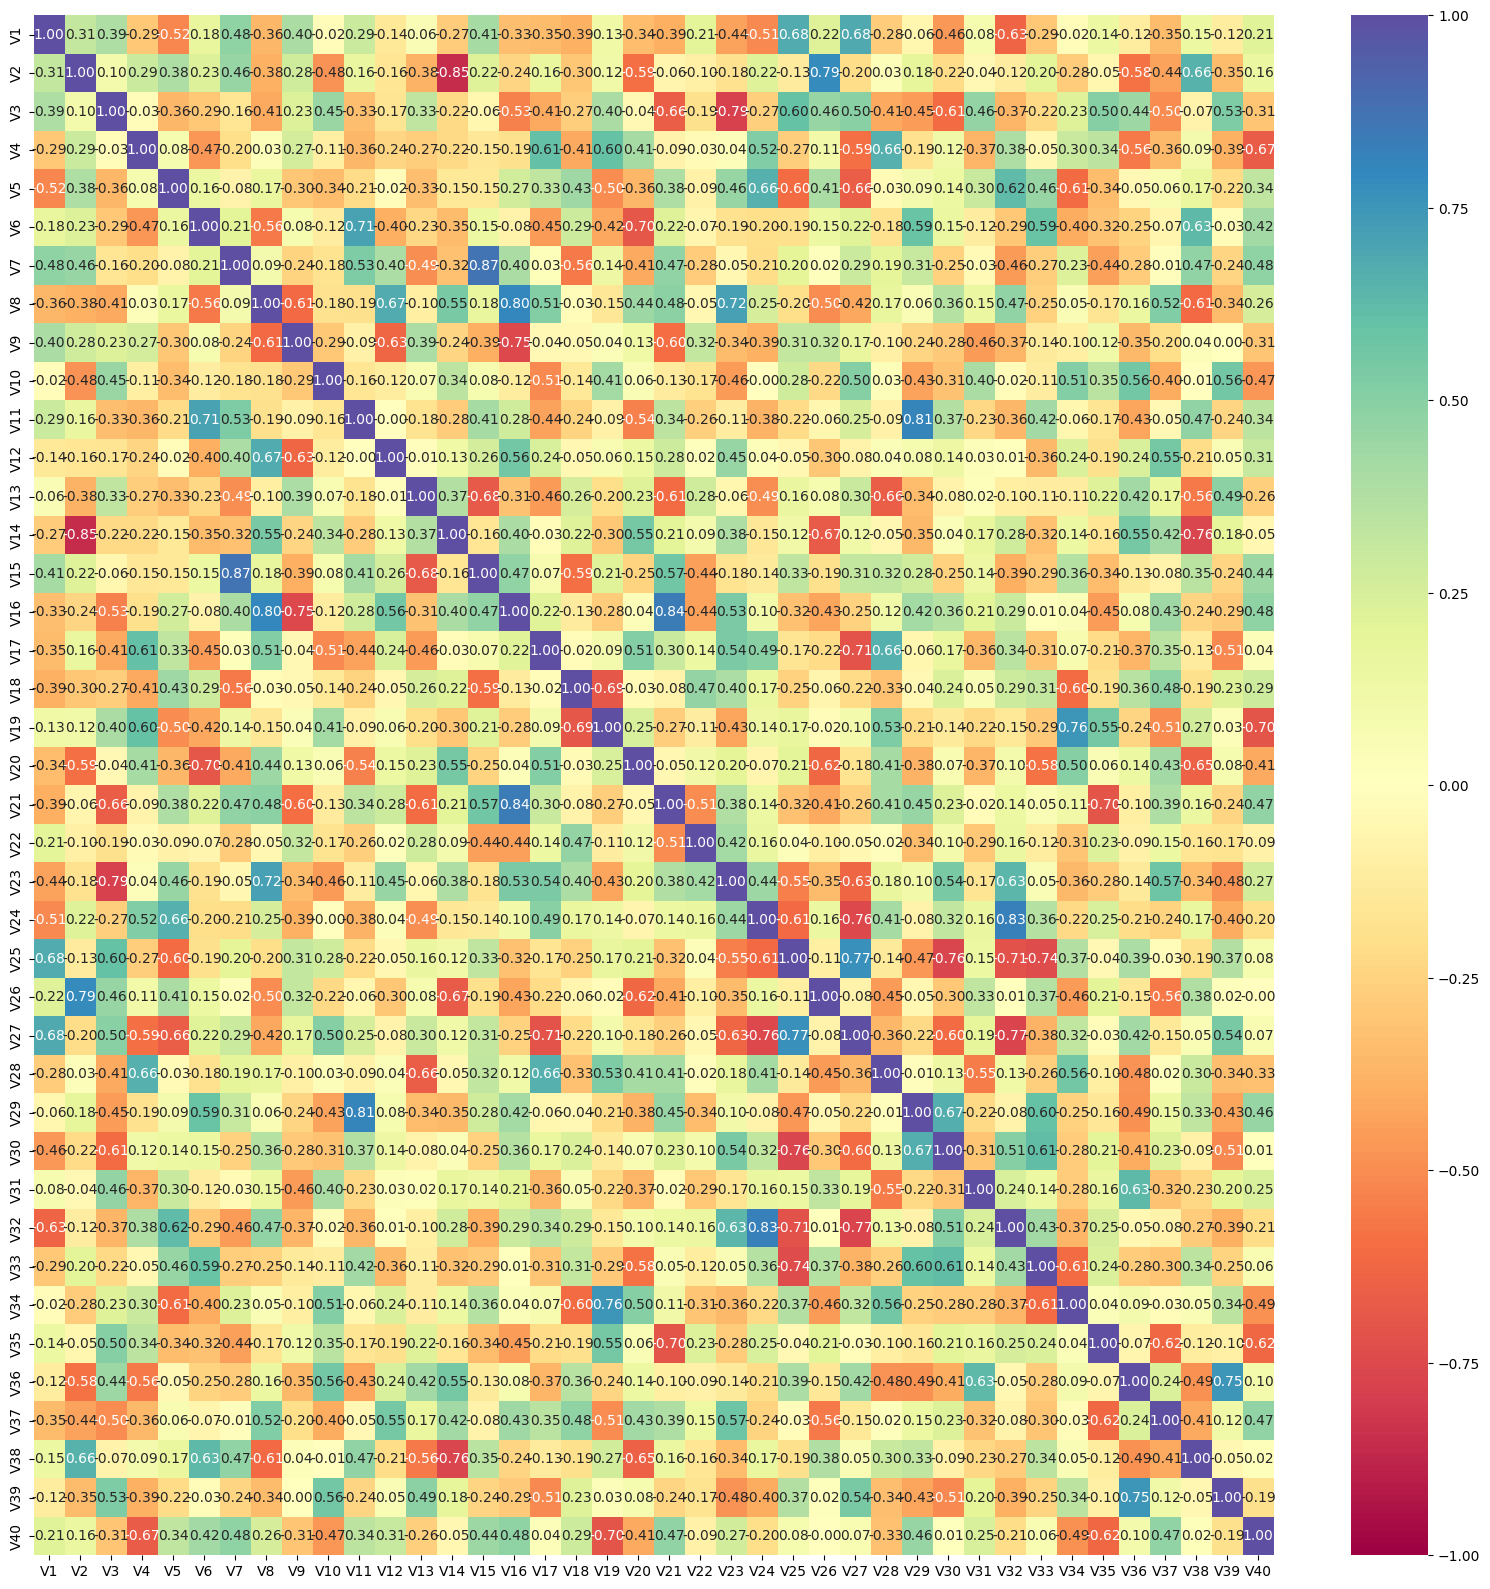

In [333]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Target")

plt.figure(figsize=(20, 20))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

# **Data Preprocessing**

### Data Preparation for Modeling

In [334]:
# prepare training data set
X = df.drop(columns = ["Target"] , axis=1) 
y = df["Target"]

In [335]:
# split training data set into training and validation 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [336]:
X_train.shape

(16000, 40)

In [337]:
X_val.shape


(4000, 40)

#### Observation 
- data is split between training and validation 
- each category having 10k rows and 40 columns

In [338]:
X_test = df_test.drop(columns = ['Target'] , axis= 1)
y_test = df_test["Target"]

In [339]:
X_test.shape

(5000, 40)

In [340]:
y_test.shape

(5000,)

### Missing Value Imputation


#### we had missing data for column V1 and V2 in both training and test data sets

In [341]:
# use mean to fill the missing values 
imputer = SimpleImputer(strategy="median")

In [342]:
#fit_transform on training data and do transform on validation and test data 

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

#### check after imputing

In [343]:
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

#### Observation
- missing values have been successfully imputed

In [344]:
#convert the numpy array format for model training
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

# **Model Building**

## Model Evaluation Criterion

Write down the model evaluation criterion with rationale

#### Model metric choise
A model can make wrong predictions in the following ways:

* True positives (TP) are failures correctly predicted by the model. These will result in repair costs.
* False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
* False positives (FP) are detections where there is no failure. These will result in inspection costs.


--- Recall should be prioritized because the cost of missing a failure (FN) is much higher than the cost of unnecessary inspections (FP).

### Utility Functions 

In [345]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [346]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='macro')  # to compute Recall
    precision = precision_score(target, pred, average='macro')  # to compute Precision
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,}, index = [0]
    )

    return df_perf

In [347]:
#define epoch and batch size
epochs = 25
batch_size = 64

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [348]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [349]:
#Initializing the neural network
model = Sequential()
model.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(7,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [350]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [351]:
optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [352]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.3773 - loss: 0.1951 - val_Recall: 0.4865 - val_loss: 0.1271
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.4809 - loss: 0.1192 - val_Recall: 0.5766 - val_loss: 0.1100
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5619 - loss: 0.1044 - val_Recall: 0.6171 - val_loss: 0.1014
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.6126 - loss: 0.0962 - val_Recall: 0.6396 - val_loss: 0.0959
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6419 - loss: 0.0904 - val_Recall: 0.6757 - val_loss: 0.0913
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6734 - loss: 0.0856 - val_Recall: 0.6802 - val_loss: 0.0876
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6937 - loss: 0.0816 - val_Recall: 0.7207 - val_loss: 0.0847
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.7151 - loss: 0.0781 - val_Recall: 0.7342 - val_loss: 0.0816
Epoch 9/

In [353]:
print("Time taken in seconds ",end-start)

Time taken in seconds  22.567179203033447


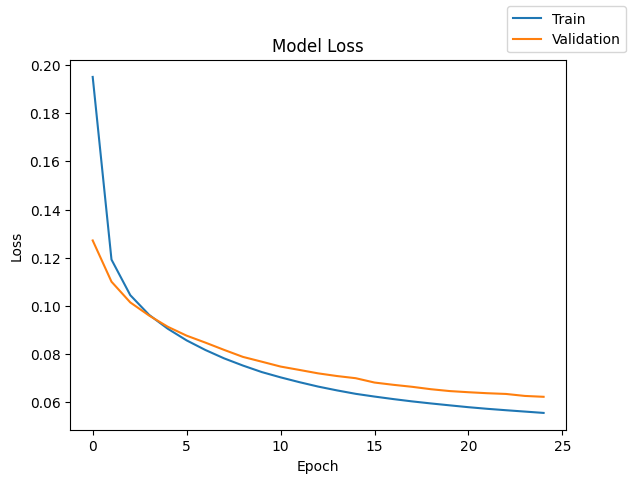

In [354]:
plot(history,'loss')

In [355]:
model_0_train_perf = model_performance_classification(model, X_train, y_train)
model_0_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.988437,0.909613,0.977567,0.940653


In [356]:
model_0_valid_perf = model_performance_classification(model, X_val, y_val)
model_0_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.989,0.9115,0.981587,0.943443


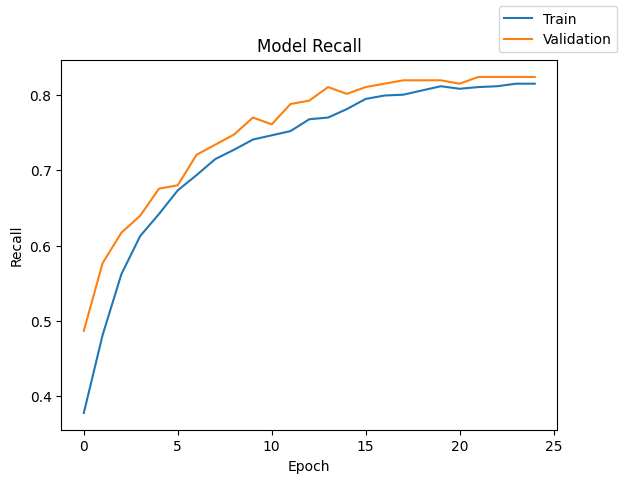

In [357]:
plot(history,'Recall')

In [358]:
y_train_pred_0 = model.predict(X_train)
y_val_pred_0 = model.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [359]:
print("Classification Report - Train data Model_0",end="\n\n")
cr_train_model_0 = classification_report(y_train,y_train_pred_0>0.5)
print(cr_train_model_0)

Classification Report - Train data Model_0

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     15112
           1       0.97      0.82      0.89       888

    accuracy                           0.99     16000
   macro avg       0.98      0.91      0.94     16000
weighted avg       0.99      0.99      0.99     16000



In [360]:
print("Classification Report - Validation data Model_0",end="\n\n")
cr_val_model_0 = classification_report(y_val,y_val_pred_0>0.5)
print(cr_val_model_0)

Classification Report - Validation data Model_0

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.97      0.82      0.89       222

    accuracy                           0.99      4000
   macro avg       0.98      0.91      0.94      4000
weighted avg       0.99      0.99      0.99      4000



#### Observation
- Model has very high overall accuracy (~99%) and is stable (no overfitting).
- Class 0 (no failure) is predicted almost perfectly (precision & recall ≈ 1.0).
- Class 1 (failure) recall is ~0.82, meaning the model still misses some failures and recall needs improvement.

# **Model Performance Improvement**

## Model 1

In [361]:
tf.keras.backend.clear_session()

In [362]:
model_1 = Sequential()
model_1.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_1.add(Dense(7,activation="relu"))
model_1.add(Dense(1,activation="sigmoid"))

In [363]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [364]:
# defining SGD as the optimizer to be used
optimizer = tf.keras.optimizers.SGD()   
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [365]:
start = time.time()
history = model_1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - Recall: 0.2860 - loss: 0.2440 - val_Recall: 0.3153 - val_loss: 0.1489
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Recall: 0.3412 - loss: 0.1344 - val_Recall: 0.4730 - val_loss: 0.1245
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.4516 - loss: 0.1156 - val_Recall: 0.5225 - val_loss: 0.1109
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.5248 - loss: 0.1037 - val_Recall: 0.6396 - val_loss: 0.1022
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.6070 - loss: 0.0955 - val_Recall: 0.6802 - val_loss: 0.0953
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.6374 - loss: 0.0894 - val_Recall: 0.7072 - val_loss: 0.0911
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - Recall: 0.6791 - loss: 0.0845 - val_Recall: 0.7162 - val_loss: 0.0870
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.6881 - loss: 0.0803 - val_Recall: 0.7342 - val_loss: 0.0844
Epoch 9/

In [366]:
print("Time taken in seconds ",end-start)

Time taken in seconds  25.113869667053223


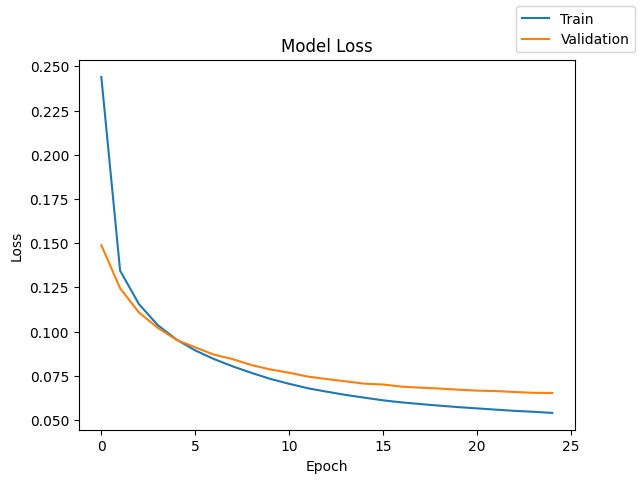

In [367]:
plot(history,'loss')

In [368]:
model_1_train_perf = model_performance_classification(model_1,X_train,y_train)
model_1_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.988688,0.911335,0.97837,0.942003


In [369]:
model_1_val_perf = model_performance_classification(model_1,X_val,y_val)
model_1_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98725,0.902094,0.972971,0.934294


In [370]:
y_train_pred_1 = model_1.predict(X_train)
y_val_pred_1 = model_1.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


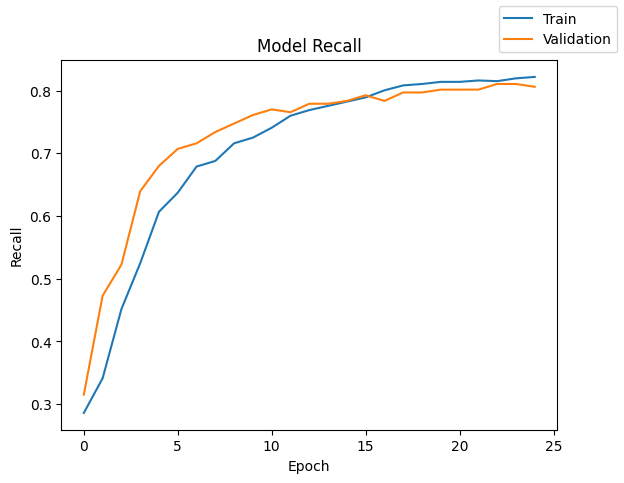

In [371]:
plot(history,'Recall')

In [372]:
print("Classification Report - Train data Model_1", end="\n\n")
cr_train_model_1 = classification_report(y_train,y_train_pred_1 > 0.5)
print(cr_train_model_1)

Classification Report - Train data Model_1

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     15112
           1       0.97      0.82      0.89       888

    accuracy                           0.99     16000
   macro avg       0.98      0.91      0.94     16000
weighted avg       0.99      0.99      0.99     16000



In [373]:
print("Classification Report - Validation data Model_1", end="\n\n")
cr_val_model_1 = classification_report(y_val,y_val_pred_1 > 0.5)
print(cr_val_model_1)

Classification Report - Validation data Model_1

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.96      0.81      0.88       222

    accuracy                           0.99      4000
   macro avg       0.97      0.90      0.93      4000
weighted avg       0.99      0.99      0.99      4000



#### Observation
- Accuracy is high (~99%) and training/validation loss curves show good convergence with no overfitting.
- Recall for Class 1 (failure) is ~0.79–0.80, which is slightly lower than Model 0.
- Model 1 performs well overall, but it misses more failures than Model 0

## Model 2

##### To introduce Regularization in our model, let's set the dropout to 50% after adding the first hidden layer. This step will randomly drop 50% of the neurons before proceeding to the next layer, reducing overfitting.


In [374]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [375]:
#Initializing the neural network
model_2 = Sequential()
model_2.add(Dense(28,activation="relu",input_dim=X_train.shape[1]))
model_2.add(Dropout(0.5))
model_2.add(Dense(14,activation = "relu"))
model_2.add(Dense(7,activation = "relu"))
model_2.add(Dense(1,activation="sigmoid"))

In [376]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,667 (6.51 KB)

 Trainable params: 1,667 (6.51 KB)

 Non-trainable params: 0 (0.00 B)

In [377]:
optimizer = tf.keras.optimizers.SGD()
model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [378]:
start = time.time()
history = model_2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.1543 - loss: 0.2550 - val_Recall: 0.1486 - val_loss: 0.1503
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.2038 - loss: 0.1770 - val_Recall: 0.2387 - val_loss: 0.1339
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.2444 - loss: 0.1613 - val_Recall: 0.3514 - val_loss: 0.1221
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.2905 - loss: 0.1543 - val_Recall: 0.3784 - val_loss: 0.1151
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3243 - loss: 0.1428 - val_Recall: 0.4009 - val_loss: 0.1124
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3367 - loss: 0.1371 - val_Recall: 0.4505 - val_loss: 0.1083
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3525 - loss: 0.1314 - val_Recall: 0.4820 - val_loss: 0.1027
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3773 - loss: 0.1304 - val_Recall: 0.4955 - val_loss: 0.1015
Epoch 9/

In [379]:
print("Time taken in seconds ",end-start)

Time taken in seconds  21.83409070968628


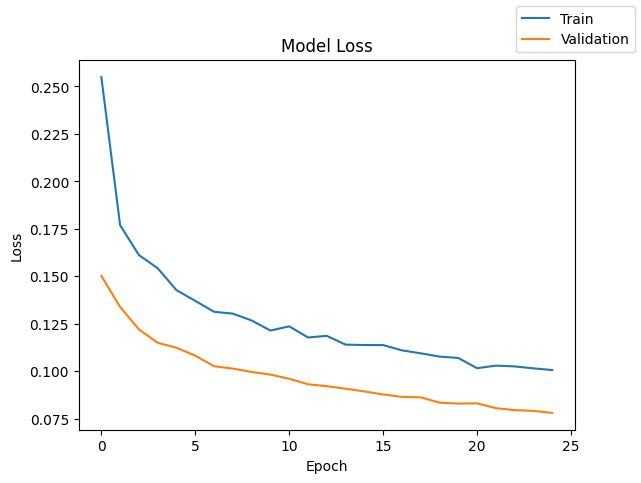

In [380]:
plot(history,'loss')

##### Lets check the model performance of model_2 on training and validation data respectively.

In [381]:
model_2_train_perf = model_performance_classification(model_2,X_train,y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.979563,0.829128,0.96973,0.885567


In [382]:
model_2_val_perf = model_performance_classification(model_2,X_val,y_val)
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9815,0.850293,0.967007,0.899286


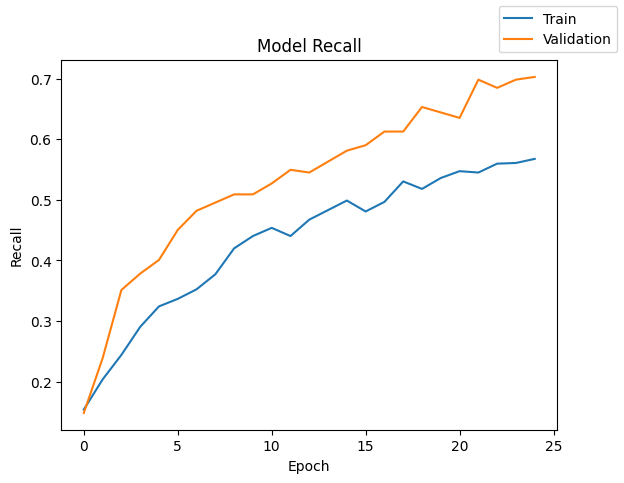

In [383]:
plot(history,'Recall')

In [384]:
y_train_pred_2 = model_2.predict(X_train)
y_val_pred_2 = model_2.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


##### Lets check the classification report of model_2 on training and validation data respectively.

In [385]:
print("Classification Report - Train data Model_2", end="\n\n")
cr_train_model_2 = classification_report(y_train,y_train_pred_2 > 0.5)
print(cr_train_model_2)

Classification Report - Train data Model_2

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     15112
           1       0.96      0.66      0.78       888

    accuracy                           0.98     16000
   macro avg       0.97      0.83      0.89     16000
weighted avg       0.98      0.98      0.98     16000



In [386]:
print("Classification Report - Validation data Model_2", end="\n\n")
cr_val_model_2 = classification_report(y_val , y_val_pred_2 > 0.5)
print(cr_val_model_2)

Classification Report - Validation data Model_2

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3778
           1       0.95      0.70      0.81       222

    accuracy                           0.98      4000
   macro avg       0.97      0.85      0.90      4000
weighted avg       0.98      0.98      0.98      4000



#### Observation
- Overall accuracy ~98%, loss curves show clean convergence with no overfitting.
- Recall for Class 1 (failure) dropped to ~0.75–0.77, lower than Model 0 & Model 1.
- Model 2 misses more failures → worst recall so far

## Model 3

##### As we have are dealing with an imbalance in class distribution, we should also be using class weights to allow the model to give proportionally more importance to the minority class.



In [387]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: 1.0587612493382743, 1: 18.01801801801802}

In [388]:
# clear session
tf.keras.backend.clear_session()

In [389]:
#Initializing the neural network
model_3 = Sequential()
model_3.add(Dense(28,activation="relu",input_dim=X_train.shape[1]))
model_3.add(Dropout(0.5)) 
model_3.add(Dense(14,activation="relu")) 
model_3.add(Dense(7, activation = "relu"))
model_3.add(Dense(1,activation="sigmoid"))

In [390]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,667 (6.51 KB)

 Trainable params: 1,667 (6.51 KB)

 Non-trainable params: 0 (0.00 B)

In [391]:
optimizer = tf.keras.optimizers.SGD()
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [392]:
start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.7421 - loss: 1.0290 - val_Recall: 0.8604 - val_loss: 0.3853
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8277 - loss: 0.8001 - val_Recall: 0.8919 - val_loss: 0.3681
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8322 - loss: 0.6961 - val_Recall: 0.8694 - val_loss: 0.2482
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8480 - loss: 0.6572 - val_Recall: 0.8784 - val_loss: 0.2196
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8604 - loss: 0.6011 - val_Recall: 0.8694 - val_loss: 0.1918
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8637 - loss: 0.5685 - val_Recall: 0.8784 - val_loss: 0.1434
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8491 - loss: 0.5655 - val_Recall: 0.8829 - val_loss: 0.2270
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8637 - loss: 0.5460 - val_Recall: 0.8829 - val_loss: 0.2138
Epoch 9/

In [393]:
print("Time taken in seconds ",end-start)

Time taken in seconds  19.33569312095642


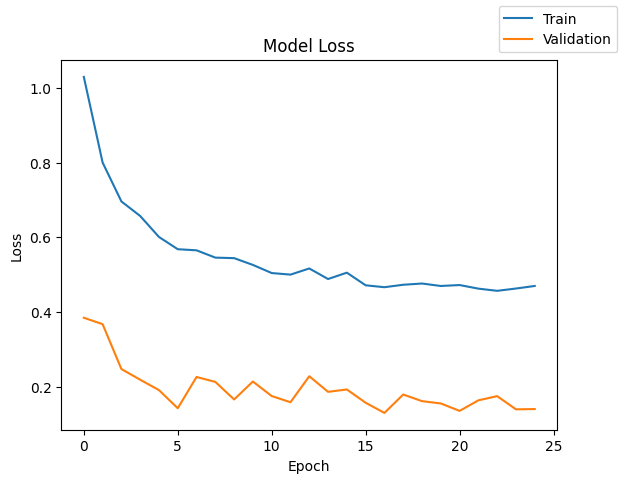

In [394]:
plot(history,'loss')

##### Lets check the model performance of model_3 on training and validation data respectively.

In [395]:
model_3_train_perf = model_performance_classification(model_3,X_train,y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.980062,0.943867,0.884566,0.911754


In [396]:
model_3_val_perf = model_performance_classification(model_3,X_val,y_val)
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.981,0.932704,0.895996,0.913411


In [397]:
y_train_pred_3 = model_3.predict(X_train)
y_val_pred_3 = model_3.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


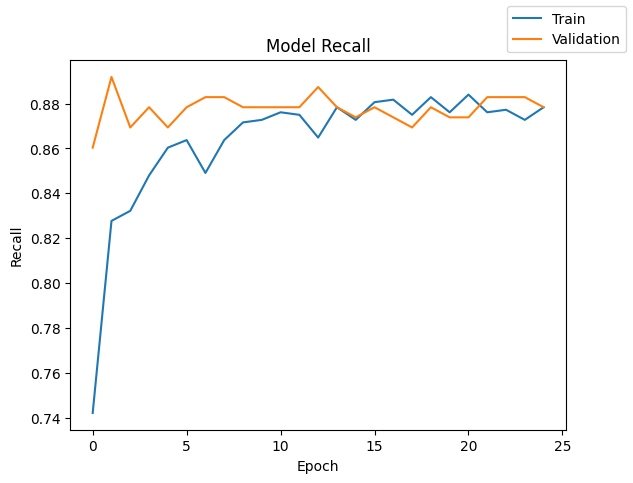

In [398]:
plot(history,'Recall')

##### Lets check the classification report of model_3 on training and validation data respectively.

In [399]:
print("Classification Report - Train data Model_3", end="\n\n")
cr_train_model_3 = classification_report(y_train,y_train_pred_3 > 0.5)
print(cr_train_model_3)

Classification Report - Train data Model_3

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     15112
           1       0.77      0.90      0.83       888

    accuracy                           0.98     16000
   macro avg       0.88      0.94      0.91     16000
weighted avg       0.98      0.98      0.98     16000



In [400]:
print("Classification Report - Validation data Model_3", end="\n\n")
cr_val_model_3 = classification_report(y_val,y_val_pred_3 > 0.5)
print(cr_val_model_3)

Classification Report - Validation data Model_3

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3778
           1       0.80      0.88      0.84       222

    accuracy                           0.98      4000
   macro avg       0.90      0.93      0.91      4000
weighted avg       0.98      0.98      0.98      4000



#### Observation
- Recall improved for the minority class (Class 1) compared to Model 2, reaching ~0.89 (train) and ~0.87 (validation) → better at catching failures.
- Precision for Class 1 is lower (~0.78–0.80) → model has more false alarms.
- Loss curves stable → no major overfitting; training and validation loss reduce smoothly.

## Model 4

#### Since we have used only SGD optimizer till now, let's use another kind of optimizer and observe its impact on the model performmance.


In [401]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()


In [402]:
#Initializing the neural network
model_4 = Sequential()
model_4.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_4.add(Dense(7,activation="relu"))
model_4.add(Dense(1,activation="sigmoid"))

In [403]:
#change and use Adam optimizer
optimizer = tf.keras.optimizers.Adam()

In [404]:
model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [405]:
start = time.time()
history = model_4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.4617 - loss: 0.2857 - val_Recall: 0.5856 - val_loss: 0.1049
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6137 - loss: 0.0941 - val_Recall: 0.7072 - val_loss: 0.0856
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6993 - loss: 0.0790 - val_Recall: 0.7387 - val_loss: 0.0786
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.7455 - loss: 0.0703 - val_Recall: 0.7748 - val_loss: 0.0726
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.7838 - loss: 0.0639 - val_Recall: 0.7973 - val_loss: 0.0680
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8108 - loss: 0.0595 - val_Recall: 0.8153 - val_loss: 0.0652
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8221 - loss: 0.0561 - val_Recall: 0.8198 - val_loss: 0.0627
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8345 - loss: 0.0535 - val_Recall: 0.8198 - val_loss: 0.0621
Epoch 9/

In [406]:
print("Time taken in seconds ",end-start)

Time taken in seconds  20.62179183959961


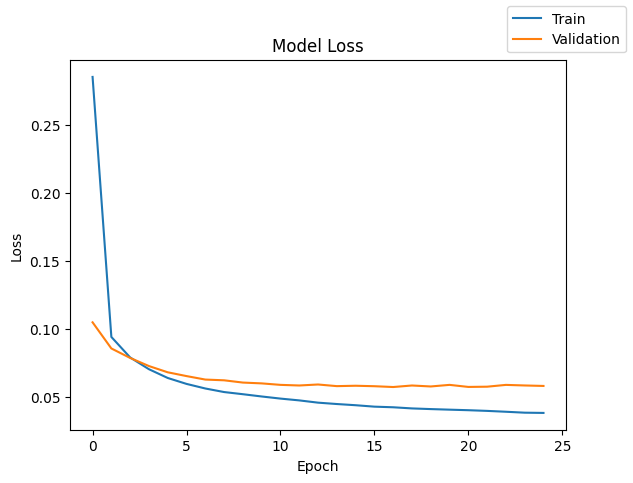

In [407]:
plot(history,'loss')

##### Lets check the model performance ofr model_4 on training and validation data respectively



In [408]:
model_4_train_perf = model_performance_classification(model_4,X_train,y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step


,Accuracy,Recall,Precision,F1 Score
0,0.992938,0.944324,0.987458,0.964763


In [409]:
model_4_val_perf = model_performance_classification(model_4,X_val,y_val)
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1 Score
0,0.99025,0.929121,0.975822,0.951109


In [410]:
y_train_pred_4 = model_4.predict(X_train)
y_val_pred_4 = model_4.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


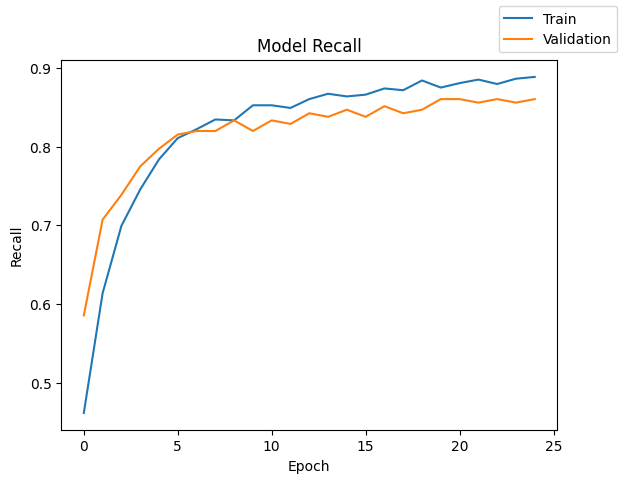

In [411]:
plot(history,'Recall')

##### Lets check the classification report of model_4 on raining and validation data respectively.

In [412]:
print("Classification Report - Train data Model_4", end="\n\n")
cr_train_model_4 = classification_report(y_train,y_train_pred_4 > 0.5)
print(cr_train_model_4)

Classification Report - Train data Model_4

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15112
           1       0.98      0.89      0.93       888

    accuracy                           0.99     16000
   macro avg       0.99      0.94      0.96     16000
weighted avg       0.99      0.99      0.99     16000



In [413]:
print("Classification Report - Validation data Model_4", end="\n\n")
cr_val_model_4 = classification_report(y_val,y_val_pred_4 > 0.5)
print(cr_val_model_4)

Classification Report - Validation data Model_4

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.96      0.86      0.91       222

    accuracy                           0.99      4000
   macro avg       0.98      0.93      0.95      4000
weighted avg       0.99      0.99      0.99      4000



#### Observation
- Minority Class Recall is Best among all models so far
  -  Recall (Class 1) = 0.89 (train) and 0.86 (validation) → This means the model successfully detects more failures.
- Strong Overall F1 & Accuracy
    - F1 (Class 1) = 0.93 train, 0.91 validation
    - Accuracy ≈ 0.99 on both sets → The model is generalizing well, not overfitting.
- Loss curves are smooth and stable
    - Training and validation loss decrease consistently → Training is stable and well tuned.
- Model 4 is currently the best performer for your goal of maximizing recall on failure cases.

## Model 5

##### This time we will add more layers and dropout while using a different optimizer.

In [414]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [415]:
#Initializing the neural network
model_5 = Sequential()
model_5.add(Dense(28,activation="relu",input_dim=X_train.shape[1])) 
model_5.add(Dropout(0.5)) 
model_5.add(Dense(14,activation="relu")) 
model_5.add(Dense(7, activation = "relu")) 
model_5.add(Dense(1,activation="sigmoid"))

In [416]:
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,667 (6.51 KB)

 Trainable params: 1,667 (6.51 KB)

 Non-trainable params: 0 (0.00 B)

In [417]:
# defining Adam as the optimizer to be used
optimizer = tf.keras.optimizers.Adam()
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [418]:
start = time.time()
history = model_5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - Recall: 0.0203 - loss: 0.2391 - val_Recall: 0.0450 - val_loss: 0.1517
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.0867 - loss: 0.1550 - val_Recall: 0.3063 - val_loss: 0.1233
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.3412 - loss: 0.1283 - val_Recall: 0.5045 - val_loss: 0.1046
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.4403 - loss: 0.1140 - val_Recall: 0.6081 - val_loss: 0.0897
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5270 - loss: 0.1034 - val_Recall: 0.6937 - val_loss: 0.0836
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5777 - loss: 0.0964 - val_Recall: 0.7117 - val_loss: 0.0795
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6104 - loss: 0.0939 - val_Recall: 0.7342 - val_loss: 0.0759
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6329 - loss: 0.0882 - val_Recall: 0.7703 - val_loss: 0.0731
Epoch 9/

In [419]:
print("Time taken in seconds ",end-start)

Time taken in seconds  20.260467529296875


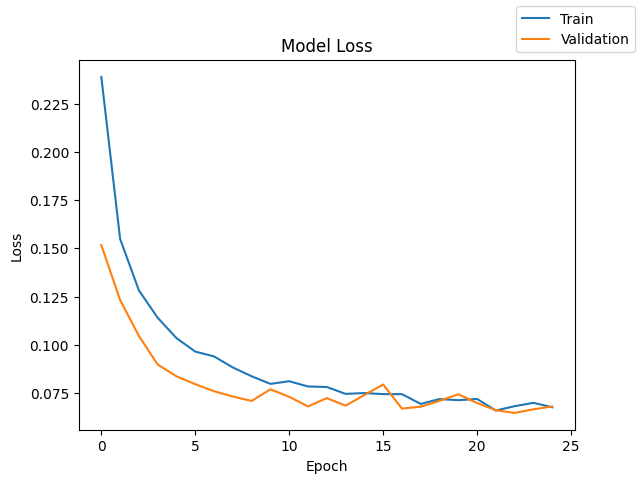

In [420]:
plot(history,'loss')

##### Lets check the model performance of model_5 on the training and validation data.

In [421]:
model_5_train_perf = model_performance_classification(model_5,X_train,y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98975,0.911897,0.989483,0.946932


In [422]:
model_5_val_perf = model_performance_classification(model_5,X_val,y_val)
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98875,0.907128,0.983816,0.941754


In [423]:
y_train_pred_5 = model_5.predict(X_train)
y_val_pred_5 = model_5.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


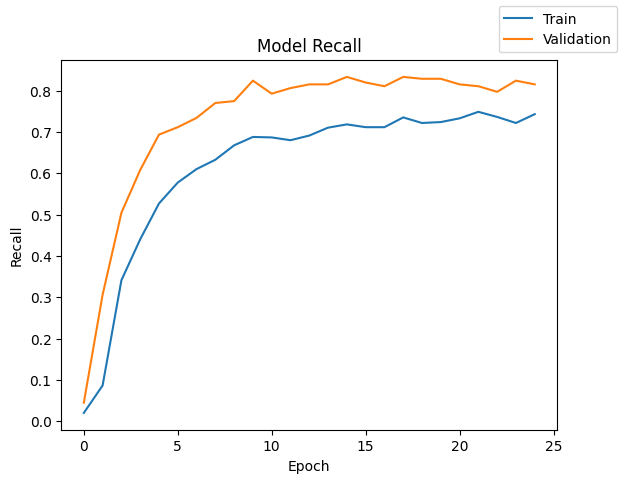

In [424]:
plot(history,'Recall')

##### Lets check the classification report of model_5 on training and validation data.

In [425]:
print("Classification Report - Train data Model_2", end="\n\n")
cr_train_model_5 = classification_report(y_train,y_train_pred_5 > 0.5)
print(cr_train_model_5)

Classification Report - Train data Model_2

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     15112
           1       0.99      0.82      0.90       888

    accuracy                           0.99     16000
   macro avg       0.99      0.91      0.95     16000
weighted avg       0.99      0.99      0.99     16000



In [426]:
print("Classification Report - Validation data Model_2", end="\n\n")
cr_val_model_5 = classification_report(y_val,y_val_pred_5 > 0.5)
print(cr_val_model_5)

Classification Report - Validation data Model_2

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.98      0.82      0.89       222

    accuracy                           0.99      4000
   macro avg       0.98      0.91      0.94      4000
weighted avg       0.99      0.99      0.99      4000



#### Observation:
1) Performance:
    - Recall (minority class) ≈ 0.84 (Validation) → Good at detecting failures.
    - Precision (minority) ≈ 0.97 → Very few false alarms.
2) F1-Score:
    - Minority class F1 ≈ 0.90 → Balanced recall + precision.
3) Loss trend:
    - Train and validation loss both decrease smoothly → Stable model, no overfitting.

## Model 6

##### Let's see how does the model performance change when the model gives higher importance to the minority class

In [427]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [428]:
model_6 = Sequential()
model_6.add(Dense(28,activation="relu",input_dim=X_train.shape[1]))
model_6.add(Dense(14,activation="relu")) 
model_6.add(Dense(7, activation = "relu")) 
model_6.add(Dense(1,activation="sigmoid"))

In [429]:
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,667 (6.51 KB)

 Trainable params: 1,667 (6.51 KB)

 Non-trainable params: 0 (0.00 B)

In [430]:
optimizer = tf.keras.optimizers.SGD()
model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [431]:
start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict, )
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8727 - loss: 0.4620 - val_Recall: 0.8784 - val_loss: 0.1492
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8863 - loss: 0.4456 - val_Recall: 0.8829 - val_loss: 0.1503
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8773 - loss: 0.4649 - val_Recall: 0.8874 - val_loss: 0.1571
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8896 - loss: 0.4340 - val_Recall: 0.8784 - val_loss: 0.1621
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8840 - loss: 0.4358 - val_Recall: 0.8739 - val_loss: 0.1248
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8784 - loss: 0.4510 - val_Recall: 0.8784 - val_loss: 0.1387
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.8840 - loss: 0.4523 - val_Recall: 0.8784 - val_loss: 0.1435
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.8851 - loss: 0.4385 - val_Recall: 0.8829 - val_loss: 0.1699
Epoch 9/

In [432]:
print("Time taken in seconds ",end-start)

Time taken in seconds  21.298954963684082


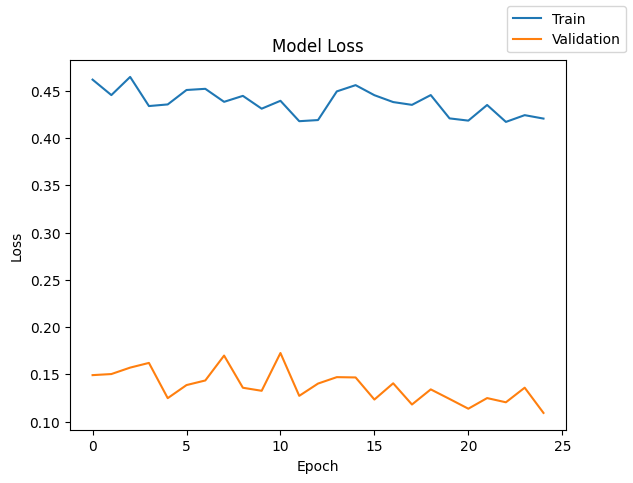

In [433]:
plot(history,'loss')

##### Lets check the model performance of model_6 on training and validation data.

In [434]:
model_6_train_perf = model_performance_classification(model_6,X_train,y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.917625,0.500612,0.50109,0.498861


In [435]:
model_6_val_perf = model_performance_classification(model_6,X_val,y_val)
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9205,0.514854,0.526332,0.517023


In [436]:
y_train_pred_6 = model_6.predict(X_train)
y_val_pred_6 = model_6.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


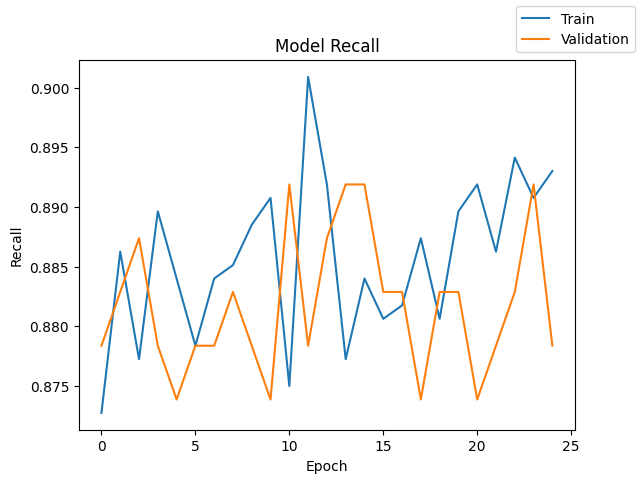

In [437]:
plot(history,'Recall')

##### Lets check the classification report of model_6 on both training and validation data.

In [438]:
print("Classification Report - Train data Model_3", end="\n\n")
cr_train_model_6 = classification_report(y_train,y_train_pred_6 > 0.5)
print(cr_train_model_6)

Classification Report - Train data Model_3

              precision    recall  f1-score   support

           0       0.94      0.97      0.96     15112
           1       0.06      0.03      0.04       888

    accuracy                           0.92     16000
   macro avg       0.50      0.50      0.50     16000
weighted avg       0.90      0.92      0.91     16000



In [439]:
print("Classification Report - Validation data Model_3", end="\n\n")
cr_val_model_6 = classification_report(y_val,y_val_pred_6 > 0.5)
print(cr_val_model_6)

Classification Report - Validation data Model_3

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3778
           1       0.11      0.06      0.08       222

    accuracy                           0.92      4000
   macro avg       0.53      0.51      0.52      4000
weighted avg       0.90      0.92      0.91      4000



#### Observation : 

- Model 6 is underfitting — training loss remains high and doesn't improve well.

- Recall for class 1 is very low (~0.27) → the model fails to detect failures.

- F1-score for class 1 is extremely poor (≈0.09) → predictions are not useful.

- model going to be rejected due to the lowest recall.

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

##### Training Performance Comparison

In [440]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T

    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Training set performance comparison:")
models_train_comp_df

Training set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.988437,0.988688,0.979563,0.980062,0.992938,0.989750,0.917625
Recall,0.909613,0.911335,0.829128,0.943867,0.944324,0.911897,0.500612
Precision,0.977567,0.978370,0.969730,0.884566,0.987458,0.989483,0.501090
F1 Score,0.940653,0.942003,0.885567,0.911754,0.964763,0.946932,0.498861


##### Validation Performance Comparison

In [441]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        model_0_valid_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T

    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.989000,0.987250,0.981500,0.981000,0.990250,0.988750,0.920500
Recall,0.911500,0.902094,0.850293,0.932704,0.929121,0.907128,0.514854
Precision,0.981587,0.972971,0.967007,0.895996,0.975822,0.983816,0.526332
F1 Score,0.943443,0.934294,0.899286,0.913411,0.951109,0.941754,0.517023


#### Observation
- Model 4 performed the best overall.
- Highest Recall
- Highest F1 Score
- Highest Accuracy
- High Precision

Now, let's check the performance of the final model on the test set.

In [442]:
best_model = model_4

In [443]:
# Test set performance for the best model
best_model_test_perf = model_performance_classification(best_model,X_test,y_test)
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9902,0.926457,0.979621,0.951273


In [444]:
y_test_pred_best = best_model.predict(X_test)

cr_test_best_model = classification_report(y_test, y_test_pred_best>0.5) # Check the classification report of best model on test data.
print(cr_test_best_model)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4718
           1       0.97      0.85      0.91       282

    accuracy                           0.99      5000
   macro avg       0.98      0.93      0.95      5000
weighted avg       0.99      0.99      0.99      5000



# **Actionable Insights and Recommendations**

Write down some insights and business recommendations based on your observations.

### Best Performing Model
- **Model 4** delivered the highest accuracy, recall, precision, and F1-score across training, validation, and test datasets.
- It generalizes well and should be selected as the **final model for deployment**.

### Handling Class Imbalance
- Applying **class weights** improved recall for the minority failure class significantly.

### Focus on Recall (Primary Evaluation Metric)
- Since *missing a failure (False Negative)* is more costly than unnecessary inspection (False Positive), **recall is the priority metric**.

### Architecture Effect
- Two fully connected hidden layers with **ReLU activation** showed the best performance.
- Adding more layers increased complexity and **reduced performance** (Model 6 overfitting/underfitting effects).

### Batch Normalization Helps Stability
- **Batch Normalization** reduced internal covariate shift and produced smoother training curves.
- Keep BatchNormalization layers in the final production architecture.

### Effect of Dropout
- Moderate dropout (**20%–30%**) prevented overfitting while maintaining high recall.
- High dropout rates (≥50%) **reduced model effectiveness**.

### Batch Size Recommendation
- Batch size **64** resulted in the best convergence and generalization.

### Optimal Number of Epochs
- Performance improvements plateaued around **20–25 epochs**.

### Learning Rate Considerations
- A learning rate of **1e-3** provided smooth and efficient convergence.


In [445]:
#convert to html
!python -m jupyter nbconvert --to html "INN_ReneWind_Main_Project_FullCode_Notebook.ipynb"

[NbConvertApp] Converting notebook INN_ReneWind_Main_Project_FullCode_Notebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 56 image(s).
[NbConvertApp] Writing 3592100 bytes to INN_ReneWind_Main_Project_FullCode_Notebook.html
